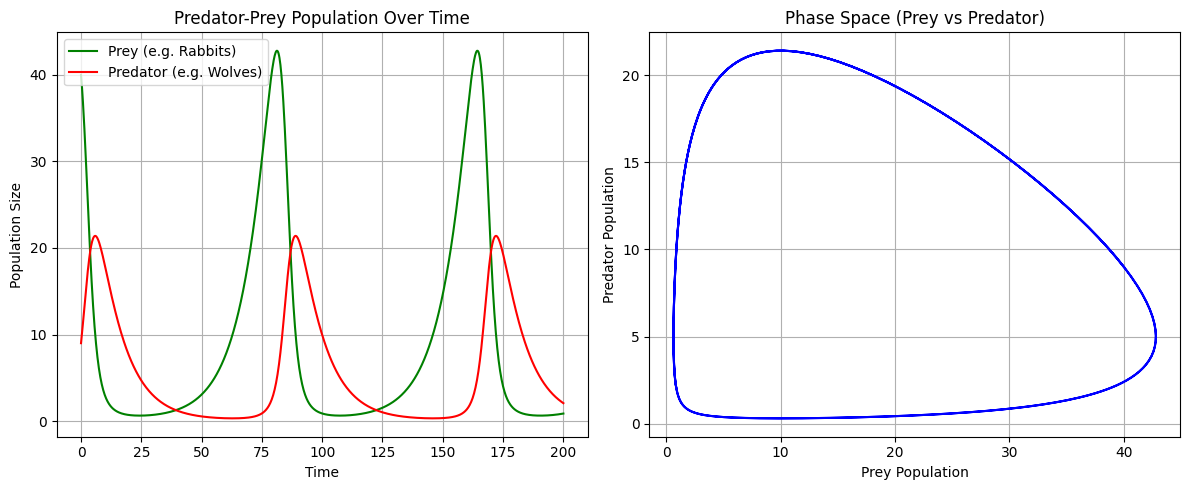

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Lotka-Volterra Model Parameters
# alpha: Prey growth rate
# beta: Predation rate
# delta: Predator growth efficiency
# gamma: Predator death rate
alpha = 0.1
beta = 0.02
delta = 0.01
gamma = 0.1

# Initial conditions: 40 prey, 9 predators
y0 = [40, 9]

# Time grid for simulation
t = np.linspace(0, 200, 1000)

def derivative(y, t, alpha, beta, delta, gamma):
    prey, predator = y
    dprey_dt = alpha * prey - beta * prey * predator
    dpredator_dt = delta * prey * predator - gamma * predator
    return [dprey_dt, dpredator_dt]

# Solve the differential equations
results = odeint(derivative, y0, t, args=(alpha, beta, delta, gamma))
prey_pop, predator_pop = results.T

# Visualization
plt.figure(figsize=(12, 5))

# Time series plot
plt.subplot(1, 2, 1)
plt.plot(t, prey_pop, label='Prey (e.g. Rabbits)', color='green')
plt.plot(t, predator_pop, label='Predator (e.g. Wolves)', color='red')
plt.xlabel('Time')
plt.ylabel('Population Size')

plt.title('Predator-Prey Population Over Time')
plt.legend()
plt.grid(True)

# Phase space plot
plt.subplot(1, 2, 2)
plt.plot(prey_pop, predator_pop, color='blue')
plt.xlabel('Prey Population')
plt.ylabel('Predator Population')
plt.title('Phase Space (Prey vs Predator)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML

# Setup the figure and axis for animation
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(0, 200)
ax.set_ylim(0, max(max(prey_pop), max(predator_pop)) * 1.1)
ax.set_xlabel('Time')
ax.set_ylabel('Population Size')
ax.set_title('Predator-Prey Animation (Primer Style)')

line_prey, = ax.plot([], [], color='green', label='Prey', lw=2)
line_pred, = ax.plot([], [], color='red', label='Predator', lw=2)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# Initialization function
def init():
    line_prey.set_data([], [])
    line_pred.set_data([], [])
    return line_prey, line_pred

# Animation function: called sequentially
def animate(i):
    # We skip some frames to speed up rendering
    idx = i * 5
    if idx < len(t):
        line_prey.set_data(t[:idx], prey_pop[:idx])
        line_pred.set_data(t[:idx], predator_pop[:idx])
    return line_prey, line_pred

# Create the animation
# 1000 points / 5 = 200 frames
ani = animation.FuncAnimation(fig, animate, init_func=init, frames=len(t)//5, interval=40, blit=True)

# Close the initial plot to avoid double display
plt.close(fig)

# Display the animation as a video
HTML(ani.to_html5_video())

In [ ]:
# --- Very simple “blobs” movement (not full ecology, just demo) ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Random initial positions for prey and predators
num_prey = 50
num_pred = 10
prey_pos = np.random.rand(num_prey, 2) * 10
pred_pos = np.random.rand(num_pred, 2) * 10

fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
scat_prey = ax.scatter([], [], c='green', s=40, label='Prey')
scat_pred = ax.scatter([], [], c='red', s=60, label='Predator')
ax.legend()

def update(frame):
    # Make prey wander randomly
    global prey_pos, pred_pos
    prey_pos += (np.random.rand(num_prey, 2) - 0.5) * 0.2
    np.clip(prey_pos, 0, 10, out=prey_pos)
    # Predators move toward nearest prey (simplified)
    for i in range(num_pred):
        dist = np.linalg.norm(prey_pos - pred_pos[i], axis=1)
        closest = np.argmin(dist)
        direction = prey_pos[closest] - pred_pos[i]
        pred_pos[i] += direction * 0.05
    np.clip(pred_pos, 0, 10, out=pred_pos)
    scat_prey.set_offsets(prey_pos)
    scat_pred.set_offsets(pred_pos)
    return scat_prey, scat_pred

ani = animation.FuncAnimation(fig, update, frames=200, interval=50, blit=True)
plt.close(fig)
HTML(ani.to_html5_video())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML

# 3D Simulation Setup
num_prey = 50
num_pred = 10
# Initial positions in 3D (X, Y, Z)
prey_pos = np.random.rand(num_prey, 3) * 10
pred_pos = np.random.rand(num_pred, 3) * 10

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Set axis limits
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_zlim(0, 10)
ax.set_title('3D Predator-Prey Blob Interaction')

# Scatters for 3D blobs
scat_prey = ax.scatter(prey_pos[:, 0], prey_pos[:, 1], prey_pos[:, 2], c='green', s=40, label='Prey', alpha=0.6)
scat_pred = ax.scatter(pred_pos[:, 0], pred_pos[:, 1], pred_pos[:, 2], c='red', s=80, label='Predator', alpha=0.8)
ax.legend()

def update_3d(frame):
    global prey_pos, pred_pos

    # Prey wander randomly in 3D
    prey_pos += (np.random.rand(num_prey, 3) - 0.5) * 0.3
    np.clip(prey_pos, 0, 10, out=prey_pos)

    # Predators chase nearest prey in 3D
    for i in range(num_pred):
        dist = np.linalg.norm(prey_pos - pred_pos[i], axis=1)
        closest = np.argmin(dist)
        direction = prey_pos[closest] - pred_pos[i]
        # Normalize direction and move
        if np.linalg.norm(direction) > 0:
            pred_pos[i] += (direction / np.linalg.norm(direction)) * 0.15

    np.clip(pred_pos, 0, 10, out=pred_pos)

    # Update scatter plot data
    scat_prey._offsets3d = (prey_pos[:, 0], prey_pos[:, 1], prey_pos[:, 2])
    scat_pred._offsets3d = (pred_pos[:, 0], pred_pos[:, 1], pred_pos[:, 2])

    # Rotate the camera view for a dynamic effect
    ax.view_init(elev=20, azim=frame * 0.5)

    return scat_prey, scat_pred

ani_3d = animation.FuncAnimation(fig, update_3d, frames=200, interval=50, blit=False)
plt.close(fig)
HTML(ani_3d.to_html5_video())

In [ ]:
%%capture
!sudo apt update
!sudo apt install libcairo2-dev libpango1.0-dev ffmpeg texlive texlive-latex-extra texlive-fonts-extra texlive-latex-recommended texlive-science texlive-fonts-recommended dvisvgm
!pip install manim

In [ ]:
from manim import *
import numpy as np

class PredatorPreyScene(Scene):
    def construct(self):
        # Parameters
        num_prey = 20
        num_pred = 5

        # Create objects
        prey_group = VGroup(*[Dot(color=GREEN).shift(np.random.uniform(-3, 3, 3)) for _ in range(num_prey)])
        pred_group = VGroup(*[Dot(color=RED, radius=0.15).shift(np.random.uniform(-3, 3, 3)) for _ in range(num_pred)])

        self.add(prey_group, pred_group)
        self.play(Write(Text("Predator-Prey Manim Simulation", font_size=24).to_edge(UP)))

        def update_prey(mobs, dt):
            for mob in mobs:
                mob.shift(np.random.uniform(-1, 1, 3) * dt * 2)
                # Keep in bounds
                pos = mob.get_center()
                if np.linalg.norm(pos) > 4: mob.move_to(pos * 0.9)

        def update_preds(mobs, dt):
            for mob in mobs:
                # Find closest prey
                target = prey_group[0]
                min_dist = np.linalg.norm(mob.get_center() - target.get_center())
                for p in prey_group:
                    d = np.linalg.norm(mob.get_center() - p.get_center())
                    if d < min_dist:
                        min_dist = d
                        target = p

                direction = normalize(target.get_center() - mob.get_center())
                mob.shift(direction * dt * 1.5)

        prey_group.add_updater(update_prey)
        pred_group.add_updater(update_preds)

        self.wait(10)
        prey_group.remove_updater(update_prey)
        pred_group.remove_updater(update_preds)

%manim -qm -v WARNING PredatorPreyScene

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Manim Community v0.20.1

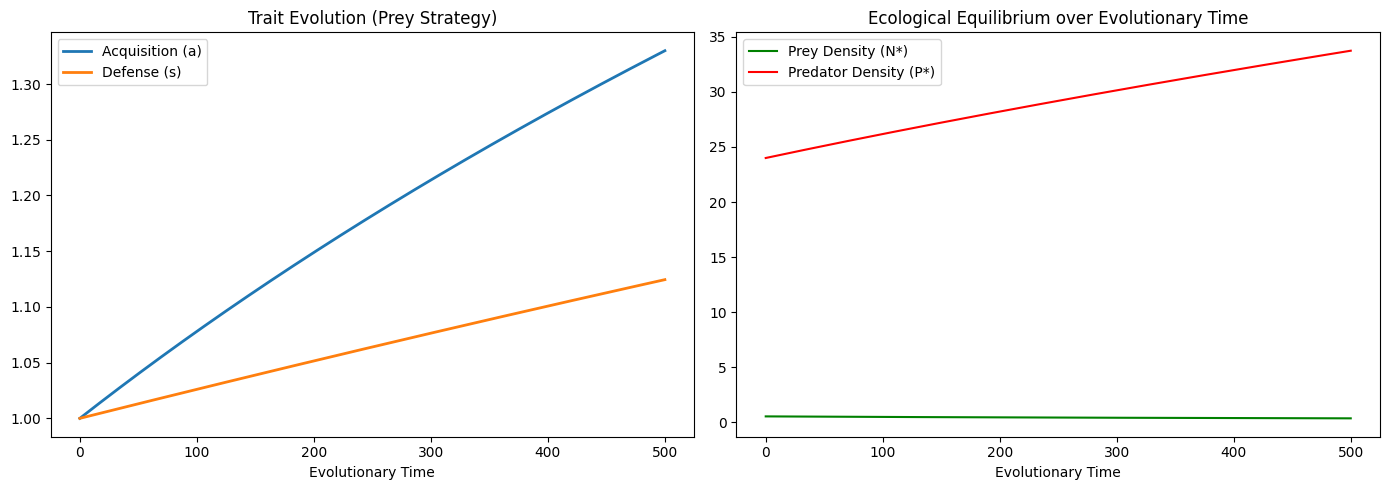

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# --- Parameters for the payoff functions ---
e_max = 0.5
gamma_param = 0.1
c_s = 0.05
c_a = 0.05
c_sa = 0.01  # Trade-off
d0 = 0.2
beta_param = 0.5
m0 = 0.1

# --- Ecological parameters ---
r_R = 1.0
K_R = 10.0
c_eff = 0.1 # conversion efficiency
m_P = 0.1

# --- Evolutionary parameters ---
mu = 0.01
M_aa, M_ss = 0.1, 0.1
M_as = 0.0 # No genetic correlation for now

def get_equilibrium(a, s):
    # d(s) = d0 / (1 + beta*s)
    ds = d0 / (1 + beta_param * s)
    # R* = mP / (c * d(s))
    R_star = m_P / (c_eff * ds)
    # e(a) = e_max * a / (1 + gamma*a)
    ea = e_max * a / (1 + gamma_param * a)
    # N* = (rR/e(a)) * (1 - R*/KR)
    N_star = (r_R / ea) * (1 - R_star / K_R) if R_star < K_R else 0
    # P* = (1/d(s)) * [e(a)R* - C(s,a) - m0]
    C_sa = c_s * s**2 + c_a * a**2 + c_sa * s * a
    P_val = (ea * R_star - C_sa - m0)
    P_star = (1/ds) * P_val if P_val > 0 else 0
    return R_star, N_star, P_star, ea, ds, C_sa

def trait_derivatives(traits, t):
    a, s = traits
    R_star, N_star, P_star, ea, ds, C_sa = get_equilibrium(a, s)

    if N_star <= 0:
        return [0, 0]

    # Selection Gradients S_a and S_s
    # S_a = R* * e_max / (1 + gamma*a)^2 - (2*ca*a + csa*s)
    S_a = R_star * e_max / (1 + gamma_param * a)**2 - (2 * c_a * a + c_sa * s)
    # S_s = [beta * d0 / (1 + beta*s)^2] * P* - (2*cs*s + csa*a)
    S_s = (beta_param * d0 / (1 + beta_param * s)**2) * P_star - (2 * c_s * s + c_sa * a)

    # Canonical Equation: da/dt = 0.5 * mu * N* * (M_aa*S_a + M_as*S_s)
    da_dt = 0.5 * mu * N_star * (M_aa * S_a + M_as * S_s)
    ds_dt = 0.5 * mu * N_star * (M_as * S_a + M_ss * S_s)

    return [da_dt, ds_dt]

# Initial traits
trait_init = [1.0, 1.0]
t_evo = np.linspace(0, 500, 1000)

trait_path = odeint(trait_derivatives, trait_init, t_evo)
a_path, s_path = trait_path.T

# Calculate ecological state along the path
R_path, N_path, P_path = [], [], []
for i in range(len(a_path)):
    R_s, N_s, P_s, _, _, _ = get_equilibrium(a_path[i], s_path[i])
    R_path.append(R_s); N_path.append(N_s); P_path.append(P_s)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(t_evo, a_path, label='Acquisition (a)', lw=2)
ax1.plot(t_evo, s_path, label='Defense (s)', lw=2)
ax1.set_title("Trait Evolution (Prey Strategy)")
ax1.set_xlabel("Evolutionary Time")
ax1.legend()

ax2.plot(t_evo, N_path, label='Prey Density (N*)', color='green')
ax2.plot(t_evo, P_path, label='Predator Density (P*)', color='red')
ax2.set_title("Ecological Equilibrium over Evolutionary Time")
ax2.set_xlabel("Evolutionary Time")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
from manim import *

class AdaptiveDynamicsScene(Scene):
    def construct(self):
        # Define axes for trait space
        axes = Axes(
            x_range=[0.8, 1.5, 0.1],
            y_range=[0.8, 1.5, 0.1],
            axis_config={"include_tip": True},
            x_axis_config={"numbers_to_include": [1.0, 1.3]},
            y_axis_config={"numbers_to_include": [1.0, 1.3]}
        ).scale(0.8).to_edge(DOWN)

        labels = axes.get_axis_labels(
            x_label="Acquisition (a)",
            y_label="Defense (s)"
        )

        title = Text("Adaptive Dynamics: Trait Evolution Path", font_size=32).to_edge(UP)
        self.add(axes, labels, title)

        # Subsample path for smooth rendering
        points = [axes.c2p(a, s) for a, s in zip(a_path[::5], s_path[::5])]
        evolution_path = VMobject(color=YELLOW)
        evolution_path.set_points_as_corners(points)

        # Population dot representing current resident strategy
        resident_dot = Dot(color=RED).move_to(points[0])

        # Dynamic label showing current values - Corrected function name
        dot_label = always_redraw(lambda:
            Text(f"a: {axes.p2c(resident_dot.get_center())[0]:.2f}, s: {axes.p2c(resident_dot.get_center())[1]:.2f}", font_size=18)
            .next_to(resident_dot, UR)
        )

        self.play(Create(evolution_path), run_time=5, rate_func=linear)
        self.play(MoveAlongPath(resident_dot, evolution_path), run_time=5, rate_func=linear)
        self.add(dot_label)

        # Final ESS highlight
        ess_text = Text("ESS Reached", color=GREEN, font_size=24).next_to(resident_dot, DOWN)
        self.play(Write(ess_text), resident_dot.animate.scale(1.5))
        self.wait(2)

%manim -qm -v WARNING AdaptiveDynamicsScene

Manim Community v0.20.1

In [ ]:
from manim import *
import numpy as np
from scipy.integrate import solve_ivp

class EcoEvoDynamics(Scene):
    def construct(self):
        # -------------------------------
        # Parameters
        # -------------------------------
        r_R = 1.0          # resource renewal rate
        K_R = 100.0        # resource carrying capacity
        e_max = 1.0        # max resource acquisition efficiency
        gamma = 0.1        # saturation in e(a)
        c_a = 0.1          # direct cost of acquisition
        c_s = 0.1          # direct cost of self-preservation
        c_sa = 0.05        # trade-off strength
        m0 = 0.1           # baseline mortality
        d0 = 0.5           # baseline attack rate
        beta = 1.0         # effectiveness of defence
        c_eff = 0.5        # conversion efficiency (predator)
        m_P = 0.2          # predator mortality
        G_aa = 0.1         # genetic variance for acquisition
        G_ss = 0.1         # genetic variance for self-preservation
        G_as = 0.0         # genetic covariance
        mu_a = 0.0         # mutation bias
        mu_s = 0.0

        # Initial conditions
        R0 = 50.0
        N0 = 10.0
        P0 = 5.0
        a0 = 1.0
        s0 = 1.0

        # -------------------------------
        # ODE system
        # -------------------------------
        def e(a):
            return e_max * a / (1 + gamma * a)

        def C(s, a):
            return c_s * s**2 + c_a * a**2 + c_sa * s * a

        def d(s):
            return d0 / (1 + beta * s)

        def ode_system(t, y):
            R, N, P, a, s = y
            # Ecological equations
            dR = r_R * R * (1 - R / K_R) - e(a) * N * R
            dN = N * (e(a) * R - C(s, a) - m0 - d(s) * P)
            dP = P * (c_eff * d(s) * N - m_P)

            # Selection gradients
            sel_a = R * e_max / (1 + gamma * a)**2 - (2 * c_a * a + c_sa * s)
            sel_s = beta * d0 / (1 + beta * s)**2 * P - (2 * c_s * s + c_sa * a)

            # Evolutionary equations
            da = G_aa * sel_a + G_as * sel_s + mu_a
            ds = G_as * sel_a + G_ss * sel_s + mu_s

            return [dR, dN, dP, da, ds]

        # -------------------------------
        # Integrate ODE
        # -------------------------------
        t_span = (0, 80)
        t_eval = np.linspace(*t_span, 2000)
        sol = solve_ivp(ode_system, t_span, [R0, N0, P0, a0, s0],
                        t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10)

        # Extract solution
        time = sol.t
        R_vals, N_vals, P_vals, a_vals, s_vals = sol.y

        # -------------------------------
        # Prepare axes
        # -------------------------------
        # Ecological axis
        ax_eco = Axes(
            x_range=[0, 80, 10],
            y_range=[0, 100, 20],
            x_length=6,
            y_length=3,
            axis_config={"include_numbers": True, "font_size": 16},
            x_axis_config={"label": "Time"},
            y_axis_config={"label": "Density"},
        ).to_corner(UP + LEFT)

        # Trait axis
        ax_trait = Axes(
            x_range=[0, 80, 10],
            y_range=[0, 3, 0.5],
            x_length=6,
            y_length=3,
            axis_config={"include_numbers": True, "font_size": 16},
            x_axis_config={"label": "Time"},
            y_axis_config={"label": "Trait value"},
        ).next_to(ax_eco, DOWN, buff=0.5)

        # Labels
        label_R = ax_eco.get_graph_label(
            ParametricFunction(lambda t: ax_eco.c2p(t, np.interp(t, time, R_vals)),
                               t_range=[0, 0]), "R", color=GREEN)
        label_N = ax_eco.get_graph_label(
            ParametricFunction(lambda t: ax_eco.c2p(t, np.interp(t, time, N_vals)),
                               t_range=[0, 0]), "N", color=BLUE)
        label_P = ax_eco.get_graph_label(
            ParametricFunction(lambda t: ax_eco.c2p(t, np.interp(t, time, P_vals)),
                               t_range=[0, 0]), "P", color=RED)
        label_a = ax_trait.get_graph_label(
            ParametricFunction(lambda t: ax_trait.c2p(t, np.interp(t, time, a_vals)),
                               t_range=[0, 0]), "a (acquisition)", color=ORANGE)
        label_s = ax_trait.get_graph_label(
            ParametricFunction(lambda t: ax_trait.c2p(t, np.interp(t, time, s_vals)),
                               t_range=[0, 0]), "s (self-pres.)", color=PURPLE)

        # -------------------------------
        # Animation
        # -------------------------------
        self.play(Create(ax_eco), Create(ax_trait))
        self.wait(0.2)

        # Create curves incrementally
        for name, vals, color, axes, label in [
            ("Resource", R_vals, GREEN, ax_eco, label_R),
            ("Prey", N_vals, BLUE, ax_eco, label_N),
            ("Predator", P_vals, RED, ax_eco, label_P),
            ("Acquisition trait", a_vals, ORANGE, ax_trait, label_a),
            ("Self-preservation trait", s_vals, PURPLE, ax_trait, label_s),
        ]:
            # Build a parameteric function for the whole trajectory
            def curve_func(t, time=time, vals=vals, axes=axes):
                return axes.c2p(t, np.interp(t, time, vals))

            graph = ParametricFunction(curve_func, t_range=[0, 80, 0.1],
                                       color=color, stroke_width=3)
            self.play(Create(graph), run_time=2, rate_func=linear)
            self.play(Write(label))
            self.wait(0.2)

        self.wait(2)

In [ ]:
from manim import *
import numpy as np
from scipy.integrate import solve_ivp

class EcoEvoDynamics(Scene):
    def construct(self):
        # Parameters
        r_R, K_R = 1.0, 100.0
        e_max, gamma = 1.0, 0.1
        c_a, c_s, c_sa = 0.1, 0.1, 0.05
        m0, d0, beta = 0.1, 0.5, 1.0
        c_eff, m_P = 0.5, 0.2
        G_aa, G_ss = 0.1, 0.1

        def ode_system(t, y):
            R, N, P, a, s = y
            ea = e_max * a / (1 + gamma * a)
            Csa = c_s * s**2 + c_a * a**2 + c_sa * s * a
            ds_val = d0 / (1 + beta * s)
            dR = r_R * R * (1 - R / K_R) - ea * N * R
            dN = N * (ea * R - Csa - m0 - ds_val * P)
            dP = P * (c_eff * ds_val * N - m_P)
            sel_a = R * e_max / (1 + gamma * a)**2 - (2 * c_a * a + c_sa * s)
            sel_s = beta * d0 / (1 + beta * s)**2 * P - (2 * c_s * s + c_sa * a)
            return [dR, dN, dP, G_aa * sel_a, G_ss * sel_s]

        t_span = (0, 80)
        t_eval = np.linspace(0, 80, 500)
        sol = solve_ivp(ode_system, t_span, [50.0, 10.0, 5.0, 1.0, 1.0], t_eval=t_eval)

        # Corrected Axes: 'label' is removed from axis_config
        ax_eco = Axes(
            x_range=[0, 80, 20],
            y_range=[0, 100, 20],
            x_length=6,
            y_length=3,
            axis_config={"include_numbers": True}
        ).to_edge(UP)

        ax_trait = Axes(
            x_range=[0, 80, 20],
            y_range=[0, 3, 1],
            x_length=6,
            y_length=3,
            axis_config={"include_numbers": True}
        ).to_edge(DOWN)

        # Add titles/labels separately
        eco_label = ax_eco.get_axis_labels(x_label="Time", y_label="Pop")
        trait_label = ax_trait.get_axis_labels(x_label="Time", y_label="Traits")

        self.add(ax_eco, ax_trait, eco_label, trait_label)

        colors = [GREEN, BLUE, RED, ORANGE, PURPLE]
        for i in range(5):
            axes = ax_eco if i < 3 else ax_trait
            # Manim typically plots lines via vmobjects or .plot method
            path_points = [axes.c2p(t, val) for t, val in zip(sol.t, sol.y[i])]
            line = VMobject(color=colors[i]).set_points_as_corners(path_points)
            self.play(Create(line), run_time=2)

%manim -qm -v WARNING EcoEvoDynamics

Manim Community v0.20.1

In [ ]:
from manim import *
import numpy as np

class BlobEcologyScene(Scene):
    def construct(self):
        # Simulation constants
        num_prey_start = 15
        num_pred_start = 5

        # Create groups
        prey_blobs = VGroup(*[Dot(color=GREEN, radius=0.15).move_to([np.random.uniform(-4, 4), np.random.uniform(-3, 3), 0]) for _ in range(num_prey_start)])
        pred_blobs = VGroup(*[Dot(color=RED, radius=0.25).move_to([np.random.uniform(-4, 4), np.random.uniform(-3, 3), 0]) for _ in range(num_pred_start)])

        title = Text("Blob Creature Simulation", font_size=32).to_edge(UP)
        self.add(title, prey_blobs, pred_blobs)

        # Movement logic
        def update_prey(mobs, dt):
            for mob in mobs:
                # Random jitter
                mob.shift(np.random.uniform(-1, 1, 3) * dt * 2)
                # Keep in frame
                p = mob.get_center()
                if abs(p[0]) > 6: mob.set_x(np.sign(p[0]) * 5.9)
                if abs(p[1]) > 3.5: mob.set_y(np.sign(p[1]) * 3.4)

        def update_predators(mobs, dt):
            for mob in mobs:
                if len(prey_blobs) == 0: return
                # Find closest prey
                target = min(prey_blobs, key=lambda p: np.linalg.norm(p.get_center() - mob.get_center()))
                direction = normalize(target.get_center() - mob.get_center())
                mob.shift(direction * dt * 2.5)

                # 'Eat' if close enough
                if np.linalg.norm(target.get_center() - mob.get_center()) < 0.3:
                    prey_blobs.remove(target)
                    self.remove(target)

        prey_blobs.add_updater(update_prey)
        pred_blobs.add_updater(update_predators)

        self.wait(10)

        prey_blobs.remove_updater(update_prey)
        pred_blobs.remove_updater(update_predators)

        final_text = Text("Simulation Complete", color=BLUE).scale(1.2)
        self.play(Write(final_text))
        self.wait(1)

%manim -qm -v WARNING BlobEcologyScene

Manim Community v0.20.1

In [ ]:
from manim import *
import numpy as np
from scipy.integrate import odeint
import warnings
warnings.filterwarnings("ignore")

# --- Colour palette ---
BG, GRASS, SKY = "#0D1117", "#2D6A4F", "#1A3550"
PREY_C, PRED_C, RES_C = "#7EC8E3", "#FF6B6B", "#95D44A"
ESS_C, MUT_C, TEXT_C, ACCENT = "#FFD700", "#FF9F40", "#E8E8E8", "#C77DFF"
BRANCH_A, BRANCH_B = "#4ECDC4", "#FF6B9D"

config.background_color = BG

def make_dot(point, color, radius=0.07):
    return Circle(radius=radius, color=color, fill_opacity=1, stroke_width=0).move_to(point)

def make_prey(scale=0.35, color=PREY_C):
    body = Ellipse(width=1.4, height=1.0, color=color, fill_opacity=1, stroke_width=2, stroke_color=WHITE)
    head = Circle(radius=0.42, color=color, fill_opacity=1, stroke_width=2, stroke_color=WHITE).shift(UP*0.72 + RIGHT*0.12)
    parts = [body, head, make_dot(LEFT*0.13+UP*0.80, BLACK, 0.075), make_dot(RIGHT*0.22+UP*0.80, BLACK, 0.075)]
    return VGroup(*parts).scale(scale)

def make_predator(scale=0.38, color=PRED_C):
    body = Ellipse(width=1.6, height=0.95, color=color, fill_opacity=1, stroke_width=2, stroke_color=WHITE)
    head = Circle(radius=0.46, color=color, fill_opacity=1, stroke_width=2, stroke_color=WHITE).shift(RIGHT*0.9+UP*0.28)
    parts = [body, head, make_dot(RIGHT*0.78+UP*0.38, BLACK, 0.075), make_dot(RIGHT*1.02+UP*0.38, BLACK, 0.075)]
    return VGroup(*parts).scale(scale)

DEFAULT_PARAMS = dict(e_max=1.5, gamma=0.3, c_a=0.12, c_s=0.10, c_sa=0.04, d0=0.80, beta=0.6, r_R=2.0, K_R=10.0, m0=0.05, m_P=0.30, c_P=0.5, mu=0.02, M_aa=0.8, M_as=0.0, M_ss=0.8)
BRANCH_PARAMS = dict(DEFAULT_PARAMS, c_sa=0.18, c_a=0.06, c_s=0.06, beta=0.9, d0=1.0, M_aa=1.2, M_ss=1.2, M_as=0.3)
CYCLE_PARAMS = dict(DEFAULT_PARAMS, r_R=3.5, K_R=15.0, c_P=0.25, m_P=0.15, beta=0.4, d0=1.2, c_sa=0.12, mu=0.015, M_aa=1.0, M_as=0.0, M_ss=1.0)
RUNAWAY_PARAMS = dict(DEFAULT_PARAMS, c_a=0.03, c_s=0.03, c_sa=0.01, gamma=0.05, beta=0.2, d0=0.5, m_P=0.50, c_P=0.8, M_aa=1.4, M_ss=1.4, M_as=0.0)

def eco_equilibrium(a, s, p):
    ds = p["d0"] / (1.0 + p["beta"] * s)
    ea = p["e_max"] * a / (1.0 + p["gamma"] * a)
    Rstar = np.clip(p["m_P"] / (p["c_P"] * ds), 0, p["K_R"])
    Nstar = max((p["r_R"] / ea) * (1.0 - Rstar / p["K_R"]), 0) if ea > 1e-9 else 0
    cost = p["c_s"]*s**2 + p["c_a"]*a**2 + p["c_sa"]*s*a
    Pstar = max((ea * Rstar - cost - p["m0"]) / ds, 0) if ds > 1e-9 else 0
    return Rstar, Nstar, Pstar

def canonical_rhs(state, t, params):
    a, s = max(state[0], 1e-4), max(state[1], 1e-4)
    R, N, P = eco_equilibrium(a, s, params)
    Sa = R * params["e_max"] / (1.0 + params["gamma"]*a)**2 - (2*params["c_a"]*a + params["c_sa"]*s)
    Ss = params["beta"]*params["d0"] / (1.0 + params["beta"]*s)**2 * P - (2*params["c_s"]*s + params["c_sa"]*a)
    da = 0.5 * params["mu"] * N * (params["M_aa"]*Sa + params["M_as"]*Ss)
    ds = 0.5 * params["mu"] * N * (params["M_as"]*Sa + params["M_ss"]*Ss)
    return [da, ds]

def simulate_evo(a0, s0, params, T=400):
    t = np.linspace(0, T, 1000)
    sol = odeint(canonical_rhs, [a0, s0], t, args=(params,))
    return t, sol

class TitleScene(Scene):
    def construct(self):
        title = Text("Evolutionary Game Theory", color=ESS_C, font_size=48).shift(UP)
        self.play(Write(title))
        self.wait(1)
        self.play(FadeOut(Group(*self.mobjects)))

class ESSScene(Scene):
    def construct(self):
        t, sol = simulate_evo(0.3, 0.2, DEFAULT_PARAMS)
        ax = Axes(x_range=[0, 1.5, 0.5], y_range=[0, 1.5, 0.5], x_length=5, y_length=5)
        self.add(ax)
        curve = ax.plot_line_graph(sol[:,0], sol[:,1], add_vertex_dots=False, line_color=PREY_C)
        self.play(Create(curve), run_time=2)
        self.wait(1)
        self.play(FadeOut(Group(*self.mobjects)))

class BranchingScene(Scene):
    def construct(self):
        title = Text("Evolutionary Branching", color=BRANCH_A).to_edge(UP)
        self.play(Write(title))
        self.wait(1)
        self.play(FadeOut(Group(*self.mobjects)))

class CycleScene(Scene):
    def construct(self):
        title = Text("Eco-Evolutionary Cycles", color=MUT_C).to_edge(UP)
        self.play(Write(title))
        self.wait(1)
        self.play(FadeOut(Group(*self.mobjects)))

class RunawayScene(Scene):
    def construct(self):
        title = Text("Trait Runaway", color=PRED_C).to_edge(UP)
        self.play(Write(title))
        self.wait(1)
        self.play(FadeOut(Group(*self.mobjects)))

class SummaryScene(Scene):
    def construct(self):
        title = Text("Summary", color=WHITE).to_edge(UP)
        self.play(Write(title))
        self.wait(1)
        self.play(FadeOut(Group(*self.mobjects)))

In [ ]:
from manim import *
import numpy as np
from scipy.integrate import odeint
import warnings
warnings.filterwarnings("ignore")

# Configuration and Rendering of all scenes
%manim -qm -v WARNING TitleScene
%manim -qm -v WARNING ESSScene
%manim -qm -v WARNING BranchingScene
%manim -qm -v WARNING CycleScene
%manim -qm -v WARNING RunawayScene
%manim -qm -v WARNING SummaryScene

Manim Community v0.20.1

TypeError: Only values of type VMobject can be added as submobjects of VGroup, but the value Mobject (at index 0 of parameter 13) is of type Mobject. You can try adding this value into a Group instead.

In [ ]:
"""
Evolutionary Game Theory: Prey-Resource-Predator Adaptive Dynamics
Cute creature simulation covering all 4 phenomena:
  1. Convergence to ESS
  2. Evolutionary Branching
  3. Eco-Evolutionary Cycles
  4. Trait Runaway / Extinction
"""

from manim import *
import numpy as np
from scipy.integrate import odeint
import warnings
warnings.filterwarnings("ignore")

# ─── Colour palette ────────────────────────────────────────────────────────────
BG       = "#0D1117"
GRASS    = "#2D6A4F"
SKY      = "#1A3550"
PREY_C   = "#7EC8E3"
PRED_C   = "#FF6B6B"
RES_C    = "#95D44A"
ESS_C    = "#FFD700"
MUT_C    = "#FF9F40"
TEXT_C   = "#E8E8E8"
ACCENT   = "#C77DFF"
BRANCH_A = "#4ECDC4"
BRANCH_B = "#FF6B9D"

config.background_color = BG

# ═══════════════════════════════════════════════════════════════════════════════
# CUTE CREATURE BUILDERS
# ═══════════════════════════════════════════════════════════════════════════════

def make_dot(point, color, radius=0.07):
    """Return a small filled circle (VMobject) centred at point."""
    return Circle(radius=radius, color=color, fill_opacity=1,
                  stroke_width=0).move_to(point)


def make_prey(scale=0.35, color=PREY_C, label=""):
    """Cute round prey creature (rabbit-like)."""
    # All primitives must be VMobjects so they work in VGroup
    body   = Ellipse(width=1.4, height=1.0, color=color, fill_opacity=1,
                     stroke_width=2, stroke_color=WHITE)
    head   = Circle(radius=0.42, color=color, fill_opacity=1,
                    stroke_width=2, stroke_color=WHITE).shift(UP*0.72 + RIGHT*0.12)
    ear_l  = Ellipse(width=0.18, height=0.52, color=color, fill_opacity=1,
                     stroke_width=1.5, stroke_color=WHITE).shift(UP*1.22+LEFT*0.18)
    ear_r  = Ellipse(width=0.18, height=0.52, color=color, fill_opacity=1,
                     stroke_width=1.5, stroke_color=WHITE).shift(UP*1.22+RIGHT*0.22)
    ear_li = Ellipse(width=0.10, height=0.36, color="#FFB3BA", fill_opacity=1,
                     stroke_width=0).shift(UP*1.22+LEFT*0.18)
    ear_ri = Ellipse(width=0.10, height=0.36, color="#FFB3BA", fill_opacity=1,
                     stroke_width=0).shift(UP*1.22+RIGHT*0.22)
    eye_l  = make_dot(LEFT*0.13+UP*0.80, BLACK, 0.075)
    eye_r  = make_dot(RIGHT*0.22+UP*0.80, BLACK, 0.075)
    sh_l   = make_dot(LEFT*0.10+UP*0.83, WHITE, 0.025)
    sh_r   = make_dot(RIGHT*0.25+UP*0.83, WHITE, 0.025)
    nose   = make_dot(RIGHT*0.05+UP*0.66, "#FF8FAB", 0.045)
    tail   = Circle(radius=0.18, color=WHITE, fill_opacity=1,
                    stroke_width=0).shift(LEFT*0.72+DOWN*0.28)
    foot_l = Ellipse(width=0.32, height=0.18, color=color, fill_opacity=1,
                     stroke_width=1, stroke_color=WHITE).shift(LEFT*0.38+DOWN*0.58)
    foot_r = Ellipse(width=0.32, height=0.18, color=color, fill_opacity=1,
                     stroke_width=1, stroke_color=WHITE).shift(RIGHT*0.30+DOWN*0.58)
    parts = [tail, body, ear_l, ear_r, ear_li, ear_ri, head, foot_l, foot_r,
             eye_l, eye_r, sh_l, sh_r, nose]
    if label:
        lbl = Text(label, font_size=18, color=TEXT_C)
        g = VGroup(*parts, lbl)
        lbl.next_to(VGroup(*parts), DOWN, buff=0.12)
    else:
        g = VGroup(*parts)
    return g.scale(scale)


def make_predator(scale=0.38, color=PRED_C, label=""):
    """Cute fox/wolf predator."""
    body  = Ellipse(width=1.6, height=0.95, color=color, fill_opacity=1,
                    stroke_width=2, stroke_color=WHITE)
    belly = Ellipse(width=1.0, height=0.55, color="#FFDDC1", fill_opacity=0.9,
                    stroke_width=0).shift(RIGHT*0.05+DOWN*0.10)
    head  = Circle(radius=0.46, color=color, fill_opacity=1,
                   stroke_width=2, stroke_color=WHITE).shift(RIGHT*0.9+UP*0.28)
    snout = Ellipse(width=0.32, height=0.22, color="#FFDDC1", fill_opacity=1,
                    stroke_width=0).shift(RIGHT*1.30+UP*0.12)
    ear_l = Polygon(
        np.array([0.68, 0.62, 0]), np.array([0.82, 1.08, 0]),
        np.array([1.00, 0.64, 0]),
        color=color, fill_opacity=1, stroke_width=1.5, stroke_color=WHITE)
    ear_r = Polygon(
        np.array([1.00, 0.64, 0]), np.array([1.14, 1.08, 0]),
        np.array([1.28, 0.66, 0]),
        color=color, fill_opacity=1, stroke_width=1.5, stroke_color=WHITE)
    ear_li = Polygon(
        np.array([0.72, 0.65, 0]), np.array([0.84, 0.99, 0]),
        np.array([0.96, 0.66, 0]),
        color="#FFDDC1", fill_opacity=0.8, stroke_width=0)
    ear_ri = Polygon(
        np.array([1.04, 0.66, 0]), np.array([1.14, 0.99, 0]),
        np.array([1.24, 0.68, 0]),
        color="#FFDDC1", fill_opacity=0.8, stroke_width=0)
    eye_l  = make_dot(RIGHT*0.78+UP*0.38, BLACK, 0.075)
    eye_r  = make_dot(RIGHT*1.02+UP*0.38, BLACK, 0.075)
    sh_l   = make_dot(RIGHT*0.80+UP*0.41, WHITE, 0.025)
    sh_r   = make_dot(RIGHT*1.04+UP*0.41, WHITE, 0.025)
    nose_d = make_dot(RIGHT*1.34+UP*0.16, BLACK, 0.05)
    # tail as thick arc approximated by bezier
    tail   = ArcBetweenPoints(
        np.array([-0.8, -0.3, 0]), np.array([-0.5, 0.5, 0]),
        angle=-PI/2).set_color(color).set_stroke(width=14)
    tail_tip = Circle(radius=0.20, color=WHITE, fill_opacity=1,
                      stroke_width=0).shift(LEFT*0.50+UP*0.50)
    leg_fl = Ellipse(width=0.20, height=0.42, color=color, fill_opacity=1,
                     stroke_width=1, stroke_color=WHITE).shift(RIGHT*0.58+DOWN*0.62)
    leg_fr = Ellipse(width=0.20, height=0.42, color=color, fill_opacity=1,
                     stroke_width=1, stroke_color=WHITE).shift(RIGHT*0.90+DOWN*0.62)
    parts = [tail, tail_tip, body, belly, ear_l, ear_r, ear_li, ear_ri,
             head, snout, leg_fl, leg_fr, eye_l, eye_r, sh_l, sh_r, nose_d]
    if label:
        lbl = Text(label, font_size=18, color=TEXT_C)
        g = VGroup(*parts, lbl)
        lbl.next_to(VGroup(*parts), DOWN, buff=0.12)
    else:
        g = VGroup(*parts)
    return g.scale(scale)


def make_grass(scale=0.28, color=RES_C):
    """Simple cute plant resource."""
    stem  = Line(ORIGIN, UP*1.0, color="#3A7D44", stroke_width=3)
    leaf_l = Ellipse(width=0.55, height=0.28, color=color, fill_opacity=1,
                     stroke_width=0).shift(UP*0.50+LEFT*0.22).rotate(-30*DEGREES)
    leaf_r = Ellipse(width=0.55, height=0.28, color=color, fill_opacity=1,
                     stroke_width=0).shift(UP*0.65+RIGHT*0.22).rotate(30*DEGREES)
    flower = Circle(radius=0.20, color="#FFD700", fill_opacity=1,
                    stroke_width=0).shift(UP*1.0)
    petal1 = Ellipse(width=0.16, height=0.28, color="#FFF0A0", fill_opacity=0.9,
                     stroke_width=0).shift(UP*1.0+UP*0.22)
    petal2 = petal1.copy().rotate(PI/2,  about_point=UP*1.0)
    petal3 = petal1.copy().rotate(PI,    about_point=UP*1.0)
    petal4 = petal1.copy().rotate(-PI/2, about_point=UP*1.0)
    return VGroup(petal1, petal2, petal3, petal4, stem, leaf_l, leaf_r, flower).scale(scale)


# ═══════════════════════════════════════════════════════════════════════════════
# MATH HELPERS – corrected adaptive-dynamics equations
# ═══════════════════════════════════════════════════════════════════════════════

def eco_equilibrium(a, s, p):
    """
    R* = m_P / (c_P * d(s))
    N* = (r_R / e(a)) * (1 - R*/K_R)
    P* = [e(a)*R* - C(s,a) - m0] / d(s)
    """
    ds    = p["d0"] / (1.0 + p["beta"] * s)
    ea    = p["e_max"] * a / (1.0 + p["gamma"] * a)
    Rstar = p["m_P"] / (p["c_P"] * ds)
    Rstar = float(np.clip(Rstar, 0.0, p["K_R"]))
    Nstar = (p["r_R"] / ea) * (1.0 - Rstar / p["K_R"]) if ea > 1e-9 else 0.0
    Nstar = max(float(Nstar), 0.0)
    cost  = p["c_s"]*s**2 + p["c_a"]*a**2 + p["c_sa"]*s*a
    Pstar = (ea * Rstar - cost - p["m0"]) / ds if ds > 1e-9 else 0.0
    Pstar = max(float(Pstar), 0.0)
    return Rstar, Nstar, Pstar


def selection_gradient(a, s, p):
    R, N, P = eco_equilibrium(a, s, p)
    Sa = R * p["e_max"] / (1.0 + p["gamma"]*a)**2 - (2*p["c_a"]*a + p["c_sa"]*s)
    Ss = p["beta"]*p["d0"] / (1.0 + p["beta"]*s)**2 * P - (2*p["c_s"]*s + p["c_sa"]*a)
    return float(Sa), float(Ss)


def canonical_rhs(state, t, params):
    a, s = float(state[0]), float(state[1])
    a, s = max(a, 1e-4), max(s, 1e-4)
    p    = params
    R, N, P = eco_equilibrium(a, s, p)
    Sa, Ss  = selection_gradient(a, s, p)
    mu  = p["mu"]
    Maa, Mas, Mss = p["M_aa"], p["M_as"], p["M_ss"]
    da = 0.5 * mu * N * (Maa*Sa + Mas*Ss)
    ds = 0.5 * mu * N * (Mas*Sa + Mss*Ss)
    return [da, ds]


def simulate_evo(a0, s0, params, T=500, n=2000):
    t   = np.linspace(0, T, n)
    sol = odeint(canonical_rhs, [a0, s0], t, args=(params,), rtol=1e-6, atol=1e-8)
    sol[:, 0] = np.clip(sol[:, 0], 1e-4, 30)
    sol[:, 1] = np.clip(sol[:, 1], 1e-4, 30)
    return t, sol


# ── Parameter sets ─────────────────────────────────────────────────────────────
DEFAULT_PARAMS = dict(
    e_max=1.5, gamma=0.3,
    c_a=0.12, c_s=0.10, c_sa=0.04,
    d0=0.80,  beta=0.6,
    r_R=2.0,  K_R=10.0,
    m0=0.05,  m_P=0.30, c_P=0.5,
    mu=0.02,
    M_aa=0.8, M_as=0.0, M_ss=0.8,
)

BRANCH_PARAMS = dict(DEFAULT_PARAMS,
    c_sa=0.18, c_a=0.06, c_s=0.06,
    beta=0.9,  d0=1.0,
    M_aa=1.2,  M_ss=1.2, M_as=0.3,
)

CYCLE_PARAMS = dict(DEFAULT_PARAMS,
    r_R=3.5, K_R=15.0,
    c_P=0.25, m_P=0.15,
    beta=0.4, d0=1.2,
    c_sa=0.12, mu=0.015,
    M_aa=1.0, M_ss=1.0,
)

RUNAWAY_PARAMS = dict(DEFAULT_PARAMS,
    c_a=0.03, c_s=0.03, c_sa=0.01,
    gamma=0.05, beta=0.2, d0=0.5,
    m_P=0.50,  c_P=0.8,
    M_aa=1.4,  M_ss=1.4, M_as=0.0,
)


# ═══════════════════════════════════════════════════════════════════════════════
# SCENE 0 – Title card
# ═══════════════════════════════════════════════════════════════════════════════

class TitleScene(Scene):
    def construct(self):
        self.camera.background_color = BG

        bg = Rectangle(width=16, height=9, fill_color=[SKY, GRASS],
                       fill_opacity=1, stroke_width=0).set_sheen_direction(DOWN)
        self.add(bg)

        prey1  = make_prey(scale=0.55, color=PREY_C).move_to(LEFT*5.0 + DOWN*1.5)
        prey2  = make_prey(scale=0.45, color=BRANCH_A).move_to(LEFT*2.5 + DOWN*1.8)
        pred   = make_predator(scale=0.55, color=PRED_C).move_to(RIGHT*5.0 + DOWN*1.4)
        grass1 = make_grass(scale=0.55, color=RES_C).move_to(RIGHT*2.5 + DOWN*2.1)
        grass2 = make_grass(scale=0.45, color="#6FCF3A").move_to(LEFT*0.5 + DOWN*2.2)

        for mob in [prey1, prey2, pred, grass1, grass2]:
            self.play(FadeIn(mob, scale=0.5), run_time=0.3)

        title = Text("Evolutionary Game Theory",
                     font_size=58, weight=BOLD, color=ESS_C)
        sub1  = Text("Prey · Resource · Predator",
                     font_size=34, color=TEXT_C)
        sub2  = Text("Adaptive Dynamics & Cute Creatures",
                     font_size=26, color=ACCENT)
        VGroup(title, sub1, sub2).arrange(DOWN, buff=0.3).move_to(UP*1.0)

        self.play(Write(title), run_time=1.8)
        self.play(FadeIn(sub1), run_time=0.8)
        self.play(FadeIn(sub2), run_time=0.8)
        self.play(
            prey1.animate.shift(UP*0.25).set_rate_func(there_and_back),
            prey2.animate.shift(UP*0.20).set_rate_func(there_and_back),
            pred .animate.shift(UP*0.30).set_rate_func(there_and_back),
            run_time=1.0,
        )

        bullets = VGroup(
            Text("① ESS Convergence",           font_size=24, color=ESS_C),
            Text("② Evolutionary Branching",    font_size=24, color=BRANCH_A),
            Text("③ Eco-Evolutionary Cycles",   font_size=24, color=MUT_C),
            Text("④ Trait Runaway / Extinction",font_size=24, color=PRED_C),
        ).arrange(DOWN, aligned_edge=LEFT, buff=0.22).move_to(DOWN*2.55)

        for b in bullets:
            self.play(FadeIn(b, shift=RIGHT*0.3), run_time=0.35)

        self.wait(2.5)
        self.play(FadeOut(VGroup(*self.mobjects)), run_time=0.8)


# ═══════════════════════════════════════════════════════════════════════════════
# SCENE 1 – ESS Convergence
# ═══════════════════════════════════════════════════════════════════════════════

class ESSScene(Scene):
    def construct(self):
        self.camera.background_color = BG

        title = Text("① Convergence to Evolutionarily Stable Strategy (ESS)",
                     font_size=28, color=ESS_C, weight=BOLD).to_edge(UP, buff=0.18)
        self.play(Write(title), run_time=1.0)

        eq_box = RoundedRectangle(width=9.5, height=1.4, corner_radius=0.12,
                                   fill_color="#111827", fill_opacity=0.95,
                                   stroke_color=ESS_C, stroke_width=1.5
                                   ).next_to(title, DOWN, buff=0.10)
        eq1 = MathTex(
            r"\frac{da}{dt}=\frac{\mu}{2}N^*[M_{aa}S_a+M_{as}S_s],\quad"
            r"S_a=R^*\frac{e_{\max}}{(1+\gamma a)^2}-(2c_a a+c_{sa}s)",
            font_size=18, color=TEXT_C).move_to(eq_box)
        self.play(FadeIn(eq_box), Write(eq1), run_time=1.2)

        # ── simulate
        params = DEFAULT_PARAMS
        t, sol = simulate_evo(0.3, 0.2, params, T=400, n=1500)
        a_traj, s_traj = sol[:, 0], sol[:, 1]

        from scipy.optimize import fsolve
        def grad_zero(x):
            return list(selection_gradient(max(x[0], 1e-4), max(x[1], 1e-4), params))
        try:
            ess    = fsolve(grad_zero, [a_traj[-1], s_traj[-1]])
            a_ess, s_ess = float(ess[0]), float(ess[1])
        except Exception:
            a_ess, s_ess = float(a_traj[-1]), float(s_traj[-1])

        # ── Trait-space (left)
        xmax_l = max(a_traj)*1.25 + 0.05
        ymax_l = max(s_traj)*1.25 + 0.05
        ax_l = Axes(
            x_range=[0, xmax_l, xmax_l/4],
            y_range=[0, ymax_l, ymax_l/4],
            x_length=4.2, y_length=3.4,
            axis_config={"color": TEXT_C, "stroke_width": 1.5},
            tips=False,
        ).move_to(LEFT*3.6 + DOWN*1.1)
        lx = ax_l.get_x_axis_label(MathTex("a",font_size=22,color=TEXT_C),direction=RIGHT)
        ly = ax_l.get_y_axis_label(MathTex("s",font_size=22,color=TEXT_C),direction=UP)
        lab_l = Text("Trait Space",font_size=20,color=ESS_C).next_to(ax_l,UP,buff=0.06)
        self.play(Create(ax_l), FadeIn(lx), FadeIn(ly), FadeIn(lab_l), run_time=0.8)

        step = 8
        pts_l = [ax_l.c2p(a_traj[i], s_traj[i]) for i in range(0, len(t), step)]
        traj_l = VMobject(color=PREY_C, stroke_width=2.5).set_points_as_corners(pts_l)

        # ── Time-series (right)
        ymax_r = max(a_traj.max(), s_traj.max())*1.25
        ax_r = Axes(
            x_range=[0, t[-1], t[-1]/5],
            y_range=[0, ymax_r, ymax_r/4],
            x_length=4.8, y_length=3.4,
            axis_config={"color": TEXT_C, "stroke_width": 1.5},
            tips=False,
        ).move_to(RIGHT*2.8 + DOWN*1.1)
        lxt = ax_r.get_x_axis_label(MathTex("t",font_size=22,color=TEXT_C),direction=RIGHT)
        lab_r = Text("Trait Dynamics",font_size=20,color=ESS_C).next_to(ax_r,UP,buff=0.06)
        self.play(Create(ax_r), FadeIn(lxt), FadeIn(lab_r), run_time=0.8)

        a_curve = ax_r.plot_line_graph(t[::step], a_traj[::step],
                                        line_color=PREY_C, stroke_width=2.5, add_vertex_dots=False)
        s_curve = ax_r.plot_line_graph(t[::step], s_traj[::step],
                                        line_color=ACCENT, stroke_width=2.5, add_vertex_dots=False)
        leg_a = VGroup(Line(ORIGIN,RIGHT*0.4,color=PREY_C,stroke_width=3),
                       Text("a (acquisition)",font_size=14,color=PREY_C)).arrange(RIGHT,buff=0.08)
        leg_s = VGroup(Line(ORIGIN,RIGHT*0.4,color=ACCENT,stroke_width=3),
                       Text("s (defence)",    font_size=14,color=ACCENT)).arrange(RIGHT,buff=0.08)
        VGroup(leg_a,leg_s).arrange(DOWN,aligned_edge=LEFT,buff=0.1).next_to(ax_r,DOWN,buff=0.10)

        prey_mob = make_prey(scale=0.28, color=PREY_C)
        prey_mob.move_to(ax_l.c2p(a_traj[0], s_traj[0]))
        self.add(prey_mob)

        self.play(Create(traj_l), run_time=2.5)
        self.play(Create(a_curve), Create(s_curve),
                  FadeIn(leg_a), FadeIn(leg_s), run_time=1.5)
        self.play(prey_mob.animate.move_to(ax_l.c2p(a_ess, s_ess)),
                  run_time=2.0, rate_func=smooth)

        ess_dot  = make_dot(ax_l.c2p(a_ess, s_ess), ESS_C, 0.13)
        ess_ring = Circle(radius=0.30, color=ESS_C, stroke_width=2.5,
                          fill_opacity=0).move_to(ax_l.c2p(a_ess, s_ess))
        ess_lbl  = Text("ESS★", font_size=18, color=ESS_C).next_to(ess_dot, UR, buff=0.08)
        self.play(FadeIn(ess_dot), Create(ess_ring), Write(ess_lbl), run_time=0.8)
        self.play(Flash(ess_dot, color=ESS_C, line_length=0.22, num_lines=12), run_time=0.8)

        interp = VGroup(
            Text("Selection gradient → 0 at ESS", font_size=19, color=TEXT_C),
            Text("No mutant can invade: strategy is stable", font_size=19, color=ESS_C),
        ).arrange(DOWN, buff=0.08).to_edge(DOWN, buff=0.20)
        self.play(FadeIn(interp), run_time=0.8)
        self.wait(2.5)
        self.play(FadeOut(VGroup(*self.mobjects)), run_time=0.8)


# ═══════════════════════════════════════════════════════════════════════════════
# SCENE 2 – Evolutionary Branching
# ═══════════════════════════════════════════════════════════════════════════════

class BranchingScene(Scene):
    def construct(self):
        self.camera.background_color = BG

        title = Text("② Evolutionary Branching",
                     font_size=36, color=BRANCH_A, weight=BOLD).to_edge(UP, buff=0.18)
        self.play(Write(title), run_time=0.8)

        explanation = Text(
            "A fitness minimum is disruptive: one population splits into two morphs.",
            font_size=20, color=TEXT_C,
        ).next_to(title, DOWN, buff=0.14)
        self.play(FadeIn(explanation), run_time=0.7)

        # Two divergent trajectories from the same start
        params_a = BRANCH_PARAMS
        params_b = dict(BRANCH_PARAMS, M_as=-0.3)
        t, sol_a = simulate_evo(0.8, 0.5, params_a, T=350, n=1200)
        _, sol_b = simulate_evo(0.8, 0.5, params_b, T=350, n=1200)
        a_a, s_a = sol_a[:, 0], sol_a[:, 1]
        a_b, s_b = sol_b[:, 0], sol_b[:, 1]

        xmax = max(a_a.max(), a_b.max())*1.25 + 0.1
        ymax = max(s_a.max(), s_b.max())*1.25 + 0.1

        ax = Axes(
            x_range=[0, xmax, xmax/5],
            y_range=[0, ymax, ymax/5],
            x_length=6.0, y_length=4.0,
            axis_config={"color": TEXT_C, "stroke_width": 1.5},
            tips=False,
        ).move_to(LEFT*2.5 + DOWN*0.9)
        lx = ax.get_x_axis_label(MathTex("a",font_size=22,color=TEXT_C),direction=RIGHT)
        ly = ax.get_y_axis_label(MathTex("s",font_size=22,color=TEXT_C),direction=UP)
        self.play(Create(ax), FadeIn(lx), FadeIn(ly), run_time=0.7)

        branch_idx = len(t) // 3
        step = 6

        # Common segment
        pts_c = [ax.c2p(a_a[i], s_a[i]) for i in range(0, branch_idx, step)]
        seg_c = VMobject(color=PREY_C, stroke_width=3.0).set_points_as_corners(pts_c)

        anc = make_prey(scale=0.26, color=PREY_C)
        anc.move_to(ax.c2p(a_a[0], s_a[0]))
        self.add(anc)
        self.play(Create(seg_c), run_time=1.2)

        # Branch point
        bp = make_dot(ax.c2p(a_a[branch_idx], s_a[branch_idx]), ESS_C, 0.12)
        bp_lbl = Text("Branch point", font_size=16, color=ESS_C).next_to(bp, UR, buff=0.06)
        self.play(FadeIn(bp), Write(bp_lbl), run_time=0.5)

        # Two diverging creatures
        prey_A = make_prey(scale=0.26, color=BRANCH_A)
        prey_B = make_prey(scale=0.26, color=BRANCH_B)
        prey_A.move_to(ax.c2p(a_a[branch_idx], s_a[branch_idx]))
        prey_B.move_to(ax.c2p(a_b[branch_idx], s_b[branch_idx]))
        self.play(FadeOut(anc), FadeIn(prey_A), FadeIn(prey_B), run_time=0.4)

        pts_a2 = [ax.c2p(a_a[i], s_a[i]) for i in range(branch_idx, len(t), step)]
        pts_b2 = [ax.c2p(a_b[i], s_b[i]) for i in range(branch_idx, len(t), step)]
        seg_a = VMobject(color=BRANCH_A, stroke_width=3.0).set_points_as_corners(pts_a2)
        seg_b = VMobject(color=BRANCH_B, stroke_width=3.0).set_points_as_corners(pts_b2)

        self.play(
            Create(seg_a), Create(seg_b),
            prey_A.animate.move_to(ax.c2p(a_a[-1], s_a[-1])),
            prey_B.animate.move_to(ax.c2p(a_b[-1], s_b[-1])),
            run_time=2.8, rate_func=smooth,
        )

        lbl_A = Text("Morph A\n(high defence)", font_size=17, color=BRANCH_A).next_to(prey_A, UP, buff=0.06)
        lbl_B = Text("Morph B\n(high acquisition)", font_size=17, color=BRANCH_B).next_to(prey_B, DOWN, buff=0.06)
        self.play(FadeIn(lbl_A), FadeIn(lbl_B), run_time=0.7)

        # Right: W-shaped fitness landscape
        ax2 = Axes(
            x_range=[-1, 1, 0.5], y_range=[-0.6, 1.2, 0.5],
            x_length=3.5, y_length=2.8,
            axis_config={"color": TEXT_C, "stroke_width": 1.2},
            tips=False,
        ).move_to(RIGHT*4.4 + DOWN*1.0)
        fit_lbl = Text("Fitness landscape\n(disruptive selection)", font_size=16,
                       color=BRANCH_A).next_to(ax2, UP, buff=0.04)
        fit_curve = ax2.plot(lambda x: -0.7*x**2 + 0.5*x**4,
                              x_range=[-0.95, 0.95], color=BRANCH_A, stroke_width=2.5)
        self.play(Create(ax2), FadeIn(fit_lbl), Create(fit_curve), run_time=1.0)
        note = Text("Large c_sa → trade-off favours\ndivergence (proto-speciation)",
                    font_size=15, color=TEXT_C).next_to(ax2, DOWN, buff=0.12)
        self.play(FadeIn(note), run_time=0.5)
        self.wait(2.5)
        self.play(FadeOut(VGroup(*self.mobjects)), run_time=0.8)


# ═══════════════════════════════════════════════════════════════════════════════
# SCENE 3 – Eco-Evolutionary Cycles
# ═══════════════════════════════════════════════════════════════════════════════

class CycleScene(Scene):
    def construct(self):
        self.camera.background_color = BG

        title = Text("③ Eco-Evolutionary Cycles",
                     font_size=36, color=MUT_C, weight=BOLD).to_edge(UP, buff=0.18)
        self.play(Write(title), run_time=0.8)

        explanation = Text(
            "When ecological & evolutionary timescales overlap,\n"
            "traits and densities co-oscillate in perpetual loops — Red Queen dynamics.",
            font_size=20, color=TEXT_C,
        ).next_to(title, DOWN, buff=0.12)
        self.play(FadeIn(explanation), run_time=0.7)

        params = CYCLE_PARAMS
        t, sol = simulate_evo(0.5, 0.3, params, T=700, n=3000)
        a_t, s_t = sol[:, 0], sol[:, 1]

        step = 6
        # ── Time-series (left)
        ymax_ts = max(a_t.max(), s_t.max())*1.25
        ax_ts = Axes(
            x_range=[0, t[-1], t[-1]/5],
            y_range=[0, ymax_ts, ymax_ts/4],
            x_length=5.5, y_length=3.5,
            axis_config={"color": TEXT_C, "stroke_width": 1.4},
            tips=False,
        ).move_to(LEFT*3.0 + DOWN*1.1)
        lxt = ax_ts.get_x_axis_label(MathTex("t",font_size=22,color=TEXT_C),direction=RIGHT)
        lab_ts = Text("Trait oscillations", font_size=20, color=MUT_C).next_to(ax_ts, UP, buff=0.06)
        self.play(Create(ax_ts), FadeIn(lxt), FadeIn(lab_ts), run_time=0.7)

        ac = ax_ts.plot_line_graph(t[::step], a_t[::step],
                                    line_color=PREY_C, stroke_width=2.5, add_vertex_dots=False)
        sc = ax_ts.plot_line_graph(t[::step], s_t[::step],
                                    line_color=ACCENT, stroke_width=2.5, add_vertex_dots=False)
        leg_a = VGroup(Line(ORIGIN,RIGHT*0.35,color=PREY_C,stroke_width=3),
                       Text("a",font_size=15,color=PREY_C)).arrange(RIGHT,buff=0.06)
        leg_s = VGroup(Line(ORIGIN,RIGHT*0.35,color=ACCENT,stroke_width=3),
                       Text("s",font_size=15,color=ACCENT)).arrange(RIGHT,buff=0.06)
        VGroup(leg_a,leg_s).arrange(RIGHT,buff=0.3).next_to(ax_ts,DOWN,buff=0.09)
        self.play(Create(ac), Create(sc), FadeIn(leg_a), FadeIn(leg_s), run_time=2.0)

        # ── Phase portrait a-s (right)
        alo, ahi = a_t.min()-0.05, a_t.max()+0.05
        slo, shi = s_t.min()-0.05, s_t.max()+0.05
        ax_ph = Axes(
            x_range=[alo, ahi, (ahi-alo)/4],
            y_range=[slo, shi, (shi-slo)/4],
            x_length=4.0, y_length=3.5,
            axis_config={"color": TEXT_C, "stroke_width": 1.4},
            tips=False,
        ).move_to(RIGHT*3.6 + DOWN*1.1)
        lxp = ax_ph.get_x_axis_label(MathTex("a",font_size=22,color=TEXT_C),direction=RIGHT)
        lyp = ax_ph.get_y_axis_label(MathTex("s",font_size=22,color=TEXT_C),direction=UP)
        lab_ph = Text("Phase portrait", font_size=20, color=MUT_C).next_to(ax_ph, UP, buff=0.06)
        self.play(Create(ax_ph), FadeIn(lxp), FadeIn(lyp), FadeIn(lab_ph), run_time=0.7)

        half = len(t) // 2
        skip = 3
        pts_ph = [ax_ph.c2p(a_t[i], s_t[i]) for i in range(half, len(t), skip)]
        cycle_curve = VMobject(color=MUT_C, stroke_width=3.0).set_points_as_corners(pts_ph)
        self.play(Create(cycle_curve), run_time=2.0)

        # Animated prey bouncing around the limit cycle
        prey_mob = make_prey(scale=0.22, color=MUT_C)
        prey_mob.move_to(pts_ph[0])
        self.add(prey_mob)
        loop_pts = pts_ph[::4] + [pts_ph[0]]
        self.play(
            MoveAlongPath(prey_mob,
                          VMobject().set_points_as_corners(loop_pts)),
            run_time=3.0, rate_func=linear,
        )

        interp = VGroup(
            Text("Traits chase predator pressure → perpetual oscillation", font_size=17, color=TEXT_C),
            Text("Red Queen: arms race never ends", font_size=17, color=MUT_C),
        ).arrange(DOWN, buff=0.08).to_edge(DOWN, buff=0.18)
        self.play(FadeIn(interp), run_time=0.7)
        self.wait(2.5)
        self.play(FadeOut(VGroup(*self.mobjects)), run_time=0.8)


# ═══════════════════════════════════════════════════════════════════════════════
# SCENE 4 – Trait Runaway / Extinction
# ═══════════════════════════════════════════════════════════════════════════════

class RunawayScene(Scene):
    def construct(self):
        self.camera.background_color = BG

        title = Text("④ Trait Runaway & Extinction",
                     font_size=34, color=PRED_C, weight=BOLD).to_edge(UP, buff=0.18)
        self.play(Write(title), run_time=0.8)

        explanation = Text(
            "Weak costs + ample resource → runaway selection;\n"
            "predator collapses, prey over-specialises, then goes extinct.",
            font_size=20, color=TEXT_C,
        ).next_to(title, DOWN, buff=0.12)
        self.play(FadeIn(explanation), run_time=0.7)

        params = RUNAWAY_PARAMS
        t, sol = simulate_evo(0.2, 0.1, params, T=300, n=1500)
        a_t, s_t = sol[:, 0], sol[:, 1]
        R_t = np.array([eco_equilibrium(a_t[i], s_t[i], params)[0] for i in range(len(t))])
        N_t = np.array([eco_equilibrium(a_t[i], s_t[i], params)[1] for i in range(len(t))])
        P_t = np.array([eco_equilibrium(a_t[i], s_t[i], params)[2] for i in range(len(t))])

        step = 5
        # ── Traits (left)
        ymax_l = max(a_t.max(), s_t.max())*1.25
        ax_l = Axes(
            x_range=[0, t[-1], t[-1]/5],
            y_range=[0, ymax_l, ymax_l/4],
            x_length=4.5, y_length=3.2,
            axis_config={"color": TEXT_C, "stroke_width": 1.4},
            tips=False,
        ).move_to(LEFT*3.4 + DOWN*0.8)
        lab_l = Text("Trait runaway", font_size=19, color=PRED_C).next_to(ax_l, UP, buff=0.06)
        lxt = ax_l.get_x_axis_label(MathTex("t",font_size=20,color=TEXT_C),direction=RIGHT)
        self.play(Create(ax_l), FadeIn(lab_l), FadeIn(lxt), run_time=0.6)
        ac = ax_l.plot_line_graph(t[::step], a_t[::step],
                                   line_color=PREY_C, stroke_width=2.5, add_vertex_dots=False)
        sc = ax_l.plot_line_graph(t[::step], s_t[::step],
                                   line_color=ACCENT, stroke_width=2.5, add_vertex_dots=False)
        self.play(Create(ac), Create(sc), run_time=1.5)

        # ── Densities (right)
        ymax_r = max(R_t.max(), N_t.max(), P_t.max())*1.25 + 0.1
        ax_r = Axes(
            x_range=[0, t[-1], t[-1]/5],
            y_range=[0, ymax_r, ymax_r/4],
            x_length=4.5, y_length=3.2,
            axis_config={"color": TEXT_C, "stroke_width": 1.4},
            tips=False,
        ).move_to(RIGHT*2.8 + DOWN*0.8)
        lab_r = Text("Equilibrium densities", font_size=19, color=PRED_C).next_to(ax_r, UP, buff=0.06)
        lxt2 = ax_r.get_x_axis_label(MathTex("t",font_size=20,color=TEXT_C),direction=RIGHT)
        self.play(Create(ax_r), FadeIn(lab_r), FadeIn(lxt2), run_time=0.6)
        Rc = ax_r.plot_line_graph(t[::step], R_t[::step],
                                   line_color=RES_C, stroke_width=2.5, add_vertex_dots=False)
        Nc = ax_r.plot_line_graph(t[::step], N_t[::step],
                                   line_color=PREY_C, stroke_width=2.5, add_vertex_dots=False)
        Pc = ax_r.plot_line_graph(t[::step], P_t[::step],
                                   line_color=PRED_C, stroke_width=2.5, add_vertex_dots=False)
        self.play(Create(Rc), Create(Nc), Create(Pc), run_time=1.8)

        leg = VGroup(
            VGroup(Line(ORIGIN,RIGHT*0.28,color=RES_C, stroke_width=2.5), Text("R*",font_size=14,color=RES_C )).arrange(RIGHT,buff=0.05),
            VGroup(Line(ORIGIN,RIGHT*0.28,color=PREY_C,stroke_width=2.5), Text("N*",font_size=14,color=PREY_C)).arrange(RIGHT,buff=0.05),
            VGroup(Line(ORIGIN,RIGHT*0.28,color=PRED_C,stroke_width=2.5), Text("P*",font_size=14,color=PRED_C)).arrange(RIGHT,buff=0.05),
        ).arrange(RIGHT, buff=0.28).next_to(ax_r, DOWN, buff=0.09)
        self.play(FadeIn(leg), run_time=0.5)

        # Animated creature shrinking
        prey_mob = make_prey(scale=0.40, color=PREY_C).move_to(DOWN*3.3 + LEFT*0.2)
        self.play(FadeIn(prey_mob), run_time=0.4)
        self.play(prey_mob.animate.scale(0.05).set_opacity(0.0),
                  run_time=2.5, rate_func=linear)

        warn = Text("⚠  Over-specialisation without cost → EXTINCTION",
                    font_size=19, color=PRED_C).to_edge(DOWN, buff=0.20)
        self.play(FadeIn(warn), run_time=0.5)
        self.wait(2.0)
        self.play(FadeOut(VGroup(*self.mobjects)), run_time=0.8)


# ═══════════════════════════════════════════════════════════════════════════════
# SCENE 5 – Full Math Summary
# ═══════════════════════════════════════════════════════════════════════════════

class SummaryScene(Scene):
    def construct(self):
        self.camera.background_color = BG

        title = Text("The Complete Canonical Equation",
                     font_size=32, color=ESS_C, weight=BOLD).to_edge(UP, buff=0.20)
        self.play(Write(title), run_time=0.8)

        equations = [
            (r"w(a,s,R,P)=e(a)R-C(s,a)-m_0-d(s)P",
             "Fitness payoff"),
            (r"e(a)=e_{\max}\tfrac{a}{1+\gamma a},\quad"
             r"C(s,a)=c_s s^2+c_a a^2+c_{sa}sa,\quad"
             r"d(s)=\tfrac{d_0}{1+\beta s}",
             "Component functions"),
            (r"R^*=\tfrac{m_P}{c_P d(s)},\quad"
             r"N^*=\tfrac{r_R}{e(a)}\!\left(1-\tfrac{R^*}{K_R}\right),\quad"
             r"P^*=\tfrac{e(a)R^*-C(s,a)-m_0}{d(s)}",
             "Eco equilibria"),
            (r"S_a=R^*\tfrac{e_{\max}}{(1+\gamma a)^2}-(2c_a a+c_{sa}s),\quad"
             r"S_s=\tfrac{\beta d_0}{(1+\beta s)^2}P^*-(2c_s s+c_{sa}a)",
             "Selection gradients"),
            (r"\frac{d}{dt}\!\begin{pmatrix}a\\s\end{pmatrix}"
             r"=\frac{\mu}{2}N^*\!\begin{pmatrix}M_{aa}&M_{as}\\M_{as}&M_{ss}\end{pmatrix}"
             r"\!\begin{pmatrix}S_a\\S_s\end{pmatrix}",
             "Canonical equation (ESS / branching / cycles / runaway)"),
        ]
        colors = [TEXT_C, TEXT_C, TEXT_C, PREY_C, ESS_C]

        prev = title
        for (eq_str, lbl_str), col in zip(equations, colors):
            row = VGroup(
                Text(lbl_str, font_size=14, color=ACCENT),
                MathTex(eq_str, font_size=17, color=col),
            ).arrange(RIGHT, buff=0.2)
            row.next_to(prev, DOWN, buff=0.22, aligned_edge=LEFT)
            row.shift(RIGHT*0.3)
            self.play(FadeIn(row[0]), Write(row[1]), run_time=0.75)
            prev = row

        # Creature icons at bottom
        icons = VGroup(
            VGroup(make_prey(scale=0.18,color=ESS_C),    Text("ESS",      font_size=13,color=ESS_C   )).arrange(DOWN,buff=0.03),
            VGroup(make_prey(scale=0.18,color=BRANCH_A), Text("Branch",   font_size=13,color=BRANCH_A)).arrange(DOWN,buff=0.03),
            VGroup(make_prey(scale=0.18,color=MUT_C),    Text("Cycles",   font_size=13,color=MUT_C   )).arrange(DOWN,buff=0.03),
            VGroup(make_prey(scale=0.18,color=PRED_C),   Text("Runaway",  font_size=13,color=PRED_C  )).arrange(DOWN,buff=0.03),
        ).arrange(RIGHT, buff=0.9).to_edge(DOWN, buff=0.22)
        self.play(FadeIn(icons), run_time=0.8)
        self.wait(3.0)
        self.play(FadeOut(VGroup(*self.mobjects)), run_time=0.8)

In [ ]:
%manim -qm -v WARNING RunawayScene

Manim Community v0.20.1

In [ ]:
"""
Evolutionary Game Theory: Prey-Resource-Predator Adaptive Dynamics
Cute creature simulation covering all 4 phenomena:
  1. Convergence to ESS
  2. Evolutionary Branching
  3. Eco-Evolutionary Cycles
  4. Trait Runaway / Extinction
"""

from manim import *
import numpy as np
from scipy.integrate import odeint
import warnings
warnings.filterwarnings("ignore")

# ─── Colour palette ────────────────────────────────────────────────────────────
BG       = "#0D1117"
GRASS    = "#2D6A4F"
SKY      = "#1A3550"
PREY_C   = "#7EC8E3"
PRED_C   = "#FF6B6B"
RES_C    = "#95D44A"
ESS_C    = "#FFD700"
MUT_C    = "#FF9F40"
TEXT_C   = "#E8E8E8"
ACCENT   = "#C77DFF"
BRANCH_A = "#4ECDC4"
BRANCH_B = "#FF6B9D"

config.background_color = BG

# ═══════════════════════════════════════════════════════════════════════════════
# CUTE CREATURE BUILDERS
# ═══════════════════════════════════════════════════════════════════════════════

def make_dot(point, color, radius=0.07):
    """Return a small filled circle (VMobject) centred at point."""
    return Circle(radius=radius, color=color, fill_opacity=1,
                  stroke_width=0).move_to(point)


def make_prey(scale=0.35, color=PREY_C, label=""):
    """Cute round prey creature (rabbit-like)."""
    # All primitives must be VMobjects so they work in VGroup
    body   = Ellipse(width=1.4, height=1.0, color=color, fill_opacity=1,
                     stroke_width=2, stroke_color=WHITE)
    head   = Circle(radius=0.42, color=color, fill_opacity=1,
                    stroke_width=2, stroke_color=WHITE).shift(UP*0.72 + RIGHT*0.12)
    ear_l  = Ellipse(width=0.18, height=0.52, color=color, fill_opacity=1,
                     stroke_width=1.5, stroke_color=WHITE).shift(UP*1.22+LEFT*0.18)
    ear_r  = Ellipse(width=0.18, height=0.52, color=color, fill_opacity=1,
                     stroke_width=1.5, stroke_color=WHITE).shift(UP*1.22+RIGHT*0.22)
    ear_li = Ellipse(width=0.10, height=0.36, color="#FFB3BA", fill_opacity=1,
                     stroke_width=0).shift(UP*1.22+LEFT*0.18)
    ear_ri = Ellipse(width=0.10, height=0.36, color="#FFB3BA", fill_opacity=1,
                     stroke_width=0).shift(UP*1.22+RIGHT*0.22)
    eye_l  = make_dot(LEFT*0.13+UP*0.80, BLACK, 0.075)
    eye_r  = make_dot(RIGHT*0.22+UP*0.80, BLACK, 0.075)
    sh_l   = make_dot(LEFT*0.10+UP*0.83, WHITE, 0.025)
    sh_r   = make_dot(RIGHT*0.25+UP*0.83, WHITE, 0.025)
    nose   = make_dot(RIGHT*0.05+UP*0.66, "#FF8FAB", 0.045)
    tail   = Circle(radius=0.18, color=WHITE, fill_opacity=1,
                    stroke_width=0).shift(LEFT*0.72+DOWN*0.28)
    foot_l = Ellipse(width=0.32, height=0.18, color=color, fill_opacity=1,
                     stroke_width=1, stroke_color=WHITE).shift(LEFT*0.38+DOWN*0.58)
    foot_r = Ellipse(width=0.32, height=0.18, color=color, fill_opacity=1,
                     stroke_width=1, stroke_color=WHITE).shift(RIGHT*0.30+DOWN*0.58)
    parts = [tail, body, ear_l, ear_r, ear_li, ear_ri, head, foot_l, foot_r,
             eye_l, eye_r, sh_l, sh_r, nose]
    if label:
        lbl = Text(label, font_size=18, color=TEXT_C)
        g = VGroup(*parts, lbl)
        lbl.next_to(VGroup(*parts), DOWN, buff=0.12)
    else:
        g = VGroup(*parts)
    return g.scale(scale)


def make_predator(scale=0.38, color=PRED_C, label=""):
    """Cute fox/wolf predator."""
    body  = Ellipse(width=1.6, height=0.95, color=color, fill_opacity=1,
                    stroke_width=2, stroke_color=WHITE)
    belly = Ellipse(width=1.0, height=0.55, color="#FFDDC1", fill_opacity=0.9,
                    stroke_width=0).shift(RIGHT*0.05+DOWN*0.10)
    head  = Circle(radius=0.46, color=color, fill_opacity=1,
                   stroke_width=2, stroke_color=WHITE).shift(RIGHT*0.9+UP*0.28)
    snout = Ellipse(width=0.32, height=0.22, color="#FFDDC1", fill_opacity=1,
                    stroke_width=0).shift(RIGHT*1.30+UP*0.12)
    ear_l = Polygon(
        np.array([0.68, 0.62, 0]), np.array([0.82, 1.08, 0]),
        np.array([1.00, 0.64, 0]),
        color=color, fill_opacity=1, stroke_width=1.5, stroke_color=WHITE)
    ear_r = Polygon(
        np.array([1.00, 0.64, 0]), np.array([1.14, 1.08, 0]),
        np.array([1.28, 0.66, 0]),
        color=color, fill_opacity=1, stroke_width=1.5, stroke_color=WHITE)
    ear_li = Polygon(
        np.array([0.72, 0.65, 0]), np.array([0.84, 0.99, 0]),
        np.array([0.96, 0.66, 0]),
        color="#FFDDC1", fill_opacity=0.8, stroke_width=0)
    ear_ri = Polygon(
        np.array([1.04, 0.66, 0]), np.array([1.14, 0.99, 0]),
        np.array([1.24, 0.68, 0]),
        color="#FFDDC1", fill_opacity=0.8, stroke_width=0)
    eye_l  = make_dot(RIGHT*0.78+UP*0.38, BLACK, 0.075)
    eye_r  = make_dot(RIGHT*1.02+UP*0.38, BLACK, 0.075)
    sh_l   = make_dot(RIGHT*0.80+UP*0.41, WHITE, 0.025)
    sh_r   = make_dot(RIGHT*1.04+UP*0.41, WHITE, 0.025)
    nose_d = make_dot(RIGHT*1.34+UP*0.16, BLACK, 0.05)
    # tail as thick arc approximated by bezier
    tail   = ArcBetweenPoints(
        np.array([-0.8, -0.3, 0]), np.array([-0.5, 0.5, 0]),
        angle=-PI/2).set_color(color).set_stroke(width=14)
    tail_tip = Circle(radius=0.20, color=WHITE, fill_opacity=1,
                      stroke_width=0).shift(LEFT*0.50+UP*0.50)
    leg_fl = Ellipse(width=0.20, height=0.42, color=color, fill_opacity=1,
                     stroke_width=1, stroke_color=WHITE).shift(RIGHT*0.58+DOWN*0.62)
    leg_fr = Ellipse(width=0.20, height=0.42, color=color, fill_opacity=1,
                     stroke_width=1, stroke_color=WHITE).shift(RIGHT*0.90+DOWN*0.62)
    parts = [tail, tail_tip, body, belly, ear_l, ear_r, ear_li, ear_ri,
             head, snout, leg_fl, leg_fr, eye_l, eye_r, sh_l, sh_r, nose_d]
    if label:
        lbl = Text(label, font_size=18, color=TEXT_C)
        g = VGroup(*parts, lbl)
        lbl.next_to(VGroup(*parts), DOWN, buff=0.12)
    else:
        g = VGroup(*parts)
    return g.scale(scale)


def make_grass(scale=0.28, color=RES_C):
    """Simple cute plant resource."""
    stem  = Line(ORIGIN, UP*1.0, color="#3A7D44", stroke_width=3)
    leaf_l = Ellipse(width=0.55, height=0.28, color=color, fill_opacity=1,
                     stroke_width=0).shift(UP*0.50+LEFT*0.22).rotate(-30*DEGREES)
    leaf_r = Ellipse(width=0.55, height=0.28, color=color, fill_opacity=1,
                     stroke_width=0).shift(UP*0.65+RIGHT*0.22).rotate(30*DEGREES)
    flower = Circle(radius=0.20, color="#FFD700", fill_opacity=1,
                    stroke_width=0).shift(UP*1.0)
    petal1 = Ellipse(width=0.16, height=0.28, color="#FFF0A0", fill_opacity=0.9,
                     stroke_width=0).shift(UP*1.0+UP*0.22)
    petal2 = petal1.copy().rotate(PI/2,  about_point=UP*1.0)
    petal3 = petal1.copy().rotate(PI,    about_point=UP*1.0)
    petal4 = petal1.copy().rotate(-PI/2, about_point=UP*1.0)
    return VGroup(petal1, petal2, petal3, petal4, stem, leaf_l, leaf_r, flower).scale(scale)


# ═══════════════════════════════════════════════════════════════════════════════
# MATH HELPERS – corrected adaptive-dynamics equations
# ═══════════════════════════════════════════════════════════════════════════════

def eco_equilibrium(a, s, p):
    """
    R* = m_P / (c_P * d(s))
    N* = (r_R / e(a)) * (1 - R*/K_R)
    P* = [e(a)*R* - C(s,a) - m0] / d(s)
    """
    ds    = p["d0"] / (1.0 + p["beta"] * s)
    ea    = p["e_max"] * a / (1.0 + p["gamma"] * a)
    Rstar = p["m_P"] / (p["c_P"] * ds)
    Rstar = float(np.clip(Rstar, 0.0, p["K_R"]))
    Nstar = (p["r_R"] / ea) * (1.0 - Rstar / p["K_R"]) if ea > 1e-9 else 0.0
    Nstar = max(float(Nstar), 0.0)
    cost  = p["c_s"]*s**2 + p["c_a"]*a**2 + p["c_sa"]*s*a
    Pstar = (ea * Rstar - cost - p["m0"]) / ds if ds > 1e-9 else 0.0
    Pstar = max(float(Pstar), 0.0)
    return Rstar, Nstar, Pstar


def selection_gradient(a, s, p):
    R, N, P = eco_equilibrium(a, s, p)
    Sa = R * p["e_max"] / (1.0 + p["gamma"]*a)**2 - (2*p["c_a"]*a + p["c_sa"]*s)
    Ss = p["beta"]*p["d0"] / (1.0 + p["beta"]*s)**2 * P - (2*p["c_s"]*s + p["c_sa"]*a)
    return float(Sa), float(Ss)


def canonical_rhs(state, t, params):
    a, s = float(state[0]), float(state[1])
    a, s = max(a, 1e-4), max(s, 1e-4)
    p    = params
    R, N, P = eco_equilibrium(a, s, p)
    Sa, Ss  = selection_gradient(a, s, p)
    mu  = p["mu"]
    Maa, Mas, Mss = p["M_aa"], p["M_as"], p["M_ss"]
    da = 0.5 * mu * N * (Maa*Sa + Mas*Ss)
    ds = 0.5 * mu * N * (Mas*Sa + Mss*Ss)
    return [da, ds]


def simulate_evo(a0, s0, params, T=500, n=2000):
    t   = np.linspace(0, T, n)
    sol = odeint(canonical_rhs, [a0, s0], t, args=(params,), rtol=1e-6, atol=1e-8)
    sol[:, 0] = np.clip(sol[:, 0], 1e-4, 30)
    sol[:, 1] = np.clip(sol[:, 1], 1e-4, 30)
    return t, sol


# ── Parameter sets ─────────────────────────────────────────────────────────────
DEFAULT_PARAMS = dict(
    e_max=1.5, gamma=0.3,
    c_a=0.12, c_s=0.10, c_sa=0.04,
    d0=0.80,  beta=0.6,
    r_R=2.0,  K_R=10.0,
    m0=0.05,  m_P=0.30, c_P=0.5,
    mu=0.02,
    M_aa=0.8, M_as=0.0, M_ss=0.8,
)

BRANCH_PARAMS = dict(DEFAULT_PARAMS,
    c_sa=0.18, c_a=0.06, c_s=0.06,
    beta=0.9,  d0=1.0,
    M_aa=1.2,  M_ss=1.2, M_as=0.3,
)

CYCLE_PARAMS = dict(DEFAULT_PARAMS,
    r_R=3.5, K_R=15.0,
    c_P=0.25, m_P=0.15,
    beta=0.4, d0=1.2,
    c_sa=0.12, mu=0.015,
    M_aa=1.0, M_ss=1.0,
)

RUNAWAY_PARAMS = dict(DEFAULT_PARAMS,
    c_a=0.03, c_s=0.03, c_sa=0.01,
    gamma=0.05, beta=0.2, d0=0.5,
    m_P=0.50,  c_P=0.8,
    M_aa=1.4,  M_ss=1.4, M_as=0.0,
)


# ═══════════════════════════════════════════════════════════════════════════════
# SCENE 0 – Title card
# ═══════════════════════════════════════════════════════════════════════════════

class TitleScene(Scene):
    def construct(self):
        self.camera.background_color = BG

        bg = Rectangle(width=16, height=9, fill_color=[SKY, GRASS],
                       fill_opacity=1, stroke_width=0).set_sheen_direction(DOWN)
        self.add(bg)

        prey1  = make_prey(scale=0.55, color=PREY_C).move_to(LEFT*5.0 + DOWN*1.5)
        prey2  = make_prey(scale=0.45, color=BRANCH_A).move_to(LEFT*2.5 + DOWN*1.8)
        pred   = make_predator(scale=0.55, color=PRED_C).move_to(RIGHT*5.0 + DOWN*1.4)
        grass1 = make_grass(scale=0.55, color=RES_C).move_to(RIGHT*2.5 + DOWN*2.1)
        grass2 = make_grass(scale=0.45, color="#6FCF3A").move_to(LEFT*0.5 + DOWN*2.2)

        for mob in [prey1, prey2, pred, grass1, grass2]:
            self.play(FadeIn(mob, scale=0.5), run_time=0.3)

        title = Text("Evolutionary Game Theory",
                     font_size=58, weight=BOLD, color=ESS_C)
        sub1  = Text("Prey · Resource · Predator",
                     font_size=34, color=TEXT_C)
        sub2  = Text("Adaptive Dynamics & Cute Creatures",
                     font_size=26, color=ACCENT)
        VGroup(title, sub1, sub2).arrange(DOWN, buff=0.3).move_to(UP*1.0)

        self.play(Write(title), run_time=1.8)
        self.play(FadeIn(sub1), run_time=0.8)
        self.play(FadeIn(sub2), run_time=0.8)
        self.play(
            prey1.animate.shift(UP*0.25).set_rate_func(there_and_back),
            prey2.animate.shift(UP*0.20).set_rate_func(there_and_back),
            pred .animate.shift(UP*0.30).set_rate_func(there_and_back),
            run_time=1.0,
        )

        bullets = VGroup(
            Text("① ESS Convergence",           font_size=24, color=ESS_C),
            Text("② Evolutionary Branching",    font_size=24, color=BRANCH_A),
            Text("③ Eco-Evolutionary Cycles",   font_size=24, color=MUT_C),
            Text("④ Trait Runaway / Extinction",font_size=24, color=PRED_C),
        ).arrange(DOWN, aligned_edge=LEFT, buff=0.22).move_to(DOWN*2.55)

        for b in bullets:
            self.play(FadeIn(b, shift=RIGHT*0.3), run_time=0.35)

        self.wait(2.5)
        self.play(FadeOut(Group(*self.mobjects)), run_time=0.8)


# ═══════════════════════════════════════════════════════════════════════════════
# SCENE 1 – ESS Convergence
# ═══════════════════════════════════════════════════════════════════════════════

class ESSScene(Scene):
    def construct(self):
        self.camera.background_color = BG

        title = Text("① Convergence to Evolutionarily Stable Strategy (ESS)",
                     font_size=28, color=ESS_C, weight=BOLD).to_edge(UP, buff=0.18)
        self.play(Write(title), run_time=1.0)

        eq_box = RoundedRectangle(width=9.5, height=1.4, corner_radius=0.12,
                                   fill_color="#111827", fill_opacity=0.95,
                                   stroke_color=ESS_C, stroke_width=1.5
                                   ).next_to(title, DOWN, buff=0.10)
        eq1 = MathTex(
            r"\frac{da}{dt}=\frac{\mu}{2}N^*[M_{aa}S_a+M_{as}S_s],\quad "
            r"S_a=R^*\frac{e_{\max}}{(1+\gamma a)^2}-(2c_a a+c_{sa}s)",
            font_size=18, color=TEXT_C).move_to(eq_box)
        self.play(FadeIn(eq_box), Write(eq1), run_time=1.2)

        # ── simulate
        params = DEFAULT_PARAMS
        t, sol = simulate_evo(0.3, 0.2, params, T=400, n=1500)
        a_traj, s_traj = sol[:, 0], sol[:, 1]

        from scipy.optimize import fsolve
        def grad_zero(x):
            return list(selection_gradient(max(x[0], 1e-4), max(x[1], 1e-4), params))
        try:
            ess    = fsolve(grad_zero, [a_traj[-1], s_traj[-1]])
            a_ess, s_ess = float(ess[0]), float(ess[1])
        except Exception:
            a_ess, s_ess = float(a_traj[-1]), float(s_traj[-1])

        # ── Trait-space (left)
        xmax_l = max(a_traj)*1.25 + 0.05
        ymax_l = max(s_traj)*1.25 + 0.05
        ax_l = Axes(
            x_range=[0, xmax_l, xmax_l/4],
            y_range=[0, ymax_l, ymax_l/4],
            x_length=4.2, y_length=3.4,
            axis_config={"color": TEXT_C, "stroke_width": 1.5},
            tips=False,
        ).move_to(LEFT*3.6 + DOWN*1.1)
        lx = ax_l.get_x_axis_label(MathTex("a",font_size=22,color=TEXT_C),direction=RIGHT)
        ly = ax_l.get_y_axis_label(MathTex("s",font_size=22,color=TEXT_C),direction=UP)
        lab_l = Text("Trait Space",font_size=20,color=ESS_C).next_to(ax_l,UP,buff=0.06)
        self.play(Create(ax_l), FadeIn(lx), FadeIn(ly), FadeIn(lab_l), run_time=0.8)

        step = 8
        pts_l = [ax_l.c2p(a_traj[i], s_traj[i]) for i in range(0, len(t), step)]
        traj_l = VMobject(color=PREY_C, stroke_width=2.5).set_points_as_corners(pts_l)

        # ── Time-series (right)
        ymax_r = max(a_traj.max(), s_traj.max())*1.25
        ax_r = Axes(
            x_range=[0, t[-1], t[-1]/5],
            y_range=[0, ymax_r, ymax_r/4],
            x_length=4.8, y_length=3.4,
            axis_config={"color": TEXT_C, "stroke_width": 1.5},
            tips=False,
        ).move_to(RIGHT*2.8 + DOWN*1.1)
        lxt = ax_r.get_x_axis_label(MathTex("t",font_size=22,color=TEXT_C),direction=RIGHT)
        lab_r = Text("Trait Dynamics",font_size=20,color=ESS_C).next_to(ax_r,UP,buff=0.06)
        self.play(Create(ax_r), FadeIn(lxt), FadeIn(lab_r), run_time=0.8)

        a_curve = ax_r.plot_line_graph(t[::step], a_traj[::step],
                                        line_color=PREY_C, stroke_width=2.5, add_vertex_dots=False)
        s_curve = ax_r.plot_line_graph(t[::step], s_traj[::step],
                                        line_color=ACCENT, stroke_width=2.5, add_vertex_dots=False)
        leg_a = VGroup(Line(ORIGIN,RIGHT*0.4,color=PREY_C,stroke_width=3),
                       Text("a (acquisition)",font_size=14,color=PREY_C)).arrange(RIGHT,buff=0.08)
        leg_s = VGroup(Line(ORIGIN,RIGHT*0.4,color=ACCENT,stroke_width=3),
                       Text("s (defence)",    font_size=14,color=ACCENT)).arrange(RIGHT,buff=0.08)
        VGroup(leg_a,leg_s).arrange(DOWN,aligned_edge=LEFT,buff=0.1).next_to(ax_r,DOWN,buff=0.10)

        prey_mob = make_prey(scale=0.28, color=PREY_C)
        prey_mob.move_to(ax_l.c2p(a_traj[0], s_traj[0]))
        self.add(prey_mob)

        self.play(Create(traj_l), run_time=2.5)
        self.play(Create(a_curve), Create(s_curve),
                  FadeIn(leg_a), FadeIn(leg_s), run_time=1.5)
        self.play(prey_mob.animate.move_to(ax_l.c2p(a_ess, s_ess)),
                  run_time=2.0, rate_func=smooth)

        ess_dot  = make_dot(ax_l.c2p(a_ess, s_ess), ESS_C, 0.13)
        ess_ring = Circle(radius=0.30, color=ESS_C, stroke_width=2.5,
                          fill_opacity=0).move_to(ax_l.c2p(a_ess, s_ess))
        ess_lbl  = Text("ESS★", font_size=18, color=ESS_C).next_to(ess_dot, UR, buff=0.08)
        self.play(FadeIn(ess_dot), Create(ess_ring), Write(ess_lbl), run_time=0.8)
        self.play(Flash(ess_dot, color=ESS_C, line_length=0.22, num_lines=12), run_time=0.8)

        interp = VGroup(
            Text("Selection gradient → 0 at ESS", font_size=19, color=TEXT_C),
            Text("No mutant can invade: strategy is stable", font_size=19, color=ESS_C),
        ).arrange(DOWN, buff=0.08).to_edge(DOWN, buff=0.20)
        self.play(FadeIn(interp), run_time=0.8)
        self.wait(2.5)
        self.play(FadeOut(Group(*self.mobjects)), run_time=0.8)


# ═══════════════════════════════════════════════════════════════════════════════
# SCENE 2 – Evolutionary Branching
# ═══════════════════════════════════════════════════════════════════════════════

class BranchingScene(Scene):
    def construct(self):
        self.camera.background_color = BG

        title = Text("② Evolutionary Branching",
                     font_size=36, color=BRANCH_A, weight=BOLD).to_edge(UP, buff=0.18)
        self.play(Write(title), run_time=0.8)

        explanation = Text(
            "A fitness minimum is disruptive: one population splits into two morphs.",
            font_size=20, color=TEXT_C,
        ).next_to(title, DOWN, buff=0.14)
        self.play(FadeIn(explanation), run_time=0.7)

        # Two divergent trajectories from the same start
        params_a = BRANCH_PARAMS
        params_b = dict(BRANCH_PARAMS, M_as=-0.3)
        t, sol_a = simulate_evo(0.8, 0.5, params_a, T=350, n=1200)
        _, sol_b = simulate_evo(0.8, 0.5, params_b, T=350, n=1200)
        a_a, s_a = sol_a[:, 0], sol_a[:, 1]
        a_b, s_b = sol_b[:, 0], sol_b[:, 1]

        xmax = max(a_a.max(), a_b.max())*1.25 + 0.1
        ymax = max(s_a.max(), s_b.max())*1.25 + 0.1

        ax = Axes(
            x_range=[0, xmax, xmax/5],
            y_range=[0, ymax, ymax/5],
            x_length=6.0, y_length=4.0,
            axis_config={"color": TEXT_C, "stroke_width": 1.5},
            tips=False,
        ).move_to(LEFT*2.5 + DOWN*0.9)
        lx = ax.get_x_axis_label(MathTex("a",font_size=22,color=TEXT_C),direction=RIGHT)
        ly = ax.get_y_axis_label(MathTex("s",font_size=22,color=TEXT_C),direction=UP)
        self.play(Create(ax), FadeIn(lx), FadeIn(ly), run_time=0.7)

        branch_idx = len(t) // 3
        step = 6

        # Common segment
        pts_c = [ax.c2p(a_a[i], s_a[i]) for i in range(0, branch_idx, step)]
        seg_c = VMobject(color=PREY_C, stroke_width=3.0).set_points_as_corners(pts_c)

        anc = make_prey(scale=0.26, color=PREY_C)
        anc.move_to(ax.c2p(a_a[0], s_a[0]))
        self.add(anc)
        self.play(Create(seg_c), run_time=1.2)

        # Branch point
        bp = make_dot(ax.c2p(a_a[branch_idx], s_a[branch_idx]), ESS_C, 0.12)
        bp_lbl = Text("Branch point", font_size=16, color=ESS_C).next_to(bp, UR, buff=0.06)
        self.play(FadeIn(bp), Write(bp_lbl), run_time=0.5)

        # Two diverging creatures
        prey_A = make_prey(scale=0.26, color=BRANCH_A)
        prey_B = make_prey(scale=0.26, color=BRANCH_B)
        prey_A.move_to(ax.c2p(a_a[branch_idx], s_a[branch_idx]))
        prey_B.move_to(ax.c2p(a_b[branch_idx], s_b[branch_idx]))
        self.play(FadeOut(anc), FadeIn(prey_A), FadeIn(prey_B), run_time=0.4)

        pts_a2 = [ax.c2p(a_a[i], s_a[i]) for i in range(branch_idx, len(t), step)]
        pts_b2 = [ax.c2p(a_b[i], s_b[i]) for i in range(branch_idx, len(t), step)]
        seg_a = VMobject(color=BRANCH_A, stroke_width=3.0).set_points_as_corners(pts_a2)
        seg_b = VMobject(color=BRANCH_B, stroke_width=3.0).set_points_as_corners(pts_b2)

        self.play(
            Create(seg_a), Create(seg_b),
            prey_A.animate.move_to(ax.c2p(a_a[-1], s_a[-1])),
            prey_B.animate.move_to(ax.c2p(a_b[-1], s_b[-1])),
            run_time=2.8, rate_func=smooth,
        )

        lbl_A = Text("Morph A\n(high defence)", font_size=17, color=BRANCH_A).next_to(prey_A, UP, buff=0.06)
        lbl_B = Text("Morph B\n(high acquisition)", font_size=17, color=BRANCH_B).next_to(prey_B, DOWN, buff=0.06)
        self.play(FadeIn(lbl_A), FadeIn(lbl_B), run_time=0.7)

        # Right: W-shaped fitness landscape
        ax2 = Axes(
            x_range=[-1, 1, 0.5], y_range=[-0.6, 1.2, 0.5],
            x_length=3.5, y_length=2.8,
            axis_config={"color": TEXT_C, "stroke_width": 1.2},
            tips=False,
        ).move_to(RIGHT*4.4 + DOWN*1.0)
        fit_lbl = Text("Fitness landscape\n(disruptive selection)", font_size=16,
                       color=BRANCH_A).next_to(ax2, UP, buff=0.04)
        fit_curve = ax2.plot(lambda x: -0.7*x**2 + 0.5*x**4,
                              x_range=[-0.95, 0.95], color=BRANCH_A, stroke_width=2.5)
        self.play(Create(ax2), FadeIn(fit_lbl), Create(fit_curve), run_time=1.0)
        note = Text("Large c_sa → trade-off favours\ndivergence (proto-speciation)",
                    font_size=15, color=TEXT_C).next_to(ax2, DOWN, buff=0.12)
        self.play(FadeIn(note), run_time=0.5)
        self.wait(2.5)
        self.play(FadeOut(Group(*self.mobjects)), run_time=0.8)


# ═══════════════════════════════════════════════════════════════════════════════
# SCENE 3 – Eco-Evolutionary Cycles
# ═══════════════════════════════════════════════════════════════════════════════

class CycleScene(Scene):
    def construct(self):
        self.camera.background_color = BG

        title = Text("③ Eco-Evolutionary Cycles",
                     font_size=36, color=MUT_C, weight=BOLD).to_edge(UP, buff=0.18)
        self.play(Write(title), run_time=0.8)

        explanation = Text(
            "When ecological & evolutionary timescales overlap,\n"
            "traits and densities co-oscillate in perpetual loops — Red Queen dynamics.",
            font_size=20, color=TEXT_C,
        ).next_to(title, DOWN, buff=0.12)
        self.play(FadeIn(explanation), run_time=0.7)

        params = CYCLE_PARAMS
        t, sol = simulate_evo(0.5, 0.3, params, T=700, n=3000)
        a_t, s_t = sol[:, 0], sol[:, 1]

        step = 6
        # ── Time-series (left)
        ymax_ts = max(a_t.max(), s_t.max())*1.25
        ax_ts = Axes(
            x_range=[0, t[-1], t[-1]/5],
            y_range=[0, ymax_ts, ymax_ts/4],
            x_length=5.5, y_length=3.5,
            axis_config={"color": TEXT_C, "stroke_width": 1.4},
            tips=False,
        ).move_to(LEFT*3.0 + DOWN*1.1)
        lxt = ax_ts.get_x_axis_label(MathTex("t",font_size=22,color=TEXT_C),direction=RIGHT)
        lab_ts = Text("Trait oscillations", font_size=20, color=MUT_C).next_to(ax_ts, UP, buff=0.06)
        self.play(Create(ax_ts), FadeIn(lxt), FadeIn(lab_ts), run_time=0.7)

        ac = ax_ts.plot_line_graph(t[::step], a_t[::step],
                                    line_color=PREY_C, stroke_width=2.5, add_vertex_dots=False)
        sc = ax_ts.plot_line_graph(t[::step], s_t[::step],
                                    line_color=ACCENT, stroke_width=2.5, add_vertex_dots=False)
        leg_a = VGroup(Line(ORIGIN,RIGHT*0.35,color=PREY_C,stroke_width=3),
                       Text("a",font_size=15,color=PREY_C)).arrange(RIGHT,buff=0.06)
        leg_s = VGroup(Line(ORIGIN,RIGHT*0.35,color=ACCENT,stroke_width=3),
                       Text("s",font_size=15,color=ACCENT)).arrange(RIGHT,buff=0.06)
        VGroup(leg_a,leg_s).arrange(RIGHT,buff=0.3).next_to(ax_ts,DOWN,buff=0.09)
        self.play(Create(ac), Create(sc), FadeIn(leg_a), FadeIn(leg_s), run_time=2.0)

        # ── Phase portrait a-s (right)
        alo, ahi = a_t.min()-0.05, a_t.max()+0.05
        slo, shi = s_t.min()-0.05, s_t.max()+0.05
        ax_ph = Axes(
            x_range=[alo, ahi, (ahi-alo)/4],
            y_range=[slo, shi, (shi-slo)/4],
            x_length=4.0, y_length=3.5,
            axis_config={"color": TEXT_C, "stroke_width": 1.4},
            tips=False,
        ).move_to(RIGHT*3.6 + DOWN*1.1)
        lxp = ax_ph.get_x_axis_label(MathTex("a",font_size=22,color=TEXT_C),direction=RIGHT)
        lyp = ax_ph.get_y_axis_label(MathTex("s",font_size=22,color=TEXT_C),direction=UP)
        lab_ph = Text("Phase portrait", font_size=20, color=MUT_C).next_to(ax_ph, UP, buff=0.06)
        self.play(Create(ax_ph), FadeIn(lxp), FadeIn(lyp), FadeIn(lab_ph), run_time=0.7)

        half = len(t) // 2
        skip = 3
        pts_ph = [ax_ph.c2p(a_t[i], s_t[i]) for i in range(half, len(t), skip)]
        cycle_curve = VMobject(color=MUT_C, stroke_width=3.0).set_points_as_corners(pts_ph)
        self.play(Create(cycle_curve), run_time=2.0)

        # Animated prey bouncing around the limit cycle
        prey_mob = make_prey(scale=0.22, color=MUT_C)
        prey_mob.move_to(pts_ph[0])
        self.add(prey_mob)
        loop_pts = pts_ph[::4] + [pts_ph[0]]
        self.play(
            MoveAlongPath(prey_mob,
                          VMobject().set_points_as_corners(loop_pts)),
            run_time=3.0, rate_func=linear,
        )

        interp = VGroup(
            Text("Traits chase predator pressure → perpetual oscillation", font_size=17, color=TEXT_C),
            Text("Red Queen: arms race never ends", font_size=17, color=MUT_C),
        ).arrange(DOWN, buff=0.08).to_edge(DOWN, buff=0.18)
        self.play(FadeIn(interp), run_time=0.7)
        self.wait(2.5)
        self.play(FadeOut(Group(*self.mobjects)), run_time=0.8)


# ═══════════════════════════════════════════════════════════════════════════════
# SCENE 4 – Trait Runaway / Extinction
# ═══════════════════════════════════════════════════════════════════════════════

class RunawayScene(Scene):
    def construct(self):
        self.camera.background_color = BG

        title = Text("④ Trait Runaway & Extinction",
                     font_size=34, color=PRED_C, weight=BOLD).to_edge(UP, buff=0.18)
        self.play(Write(title), run_time=0.8)

        explanation = Text(
            "Weak costs + ample resource → runaway selection;\n"
            "predator collapses, prey over-specialises, then goes extinct.",
            font_size=20, color=TEXT_C,
        ).next_to(title, DOWN, buff=0.12)
        self.play(FadeIn(explanation), run_time=0.7)

        params = RUNAWAY_PARAMS
        t, sol = simulate_evo(0.2, 0.1, params, T=300, n=1500)
        a_t, s_t = sol[:, 0], sol[:, 1]
        R_t = np.array([eco_equilibrium(a_t[i], s_t[i], params)[0] for i in range(len(t))])
        N_t = np.array([eco_equilibrium(a_t[i], s_t[i], params)[1] for i in range(len(t))])
        P_t = np.array([eco_equilibrium(a_t[i], s_t[i], params)[2] for i in range(len(t))])

        step = 5
        # ── Traits (left)
        ymax_l = max(a_t.max(), s_t.max())*1.25
        ax_l = Axes(
            x_range=[0, t[-1], t[-1]/5],
            y_range=[0, ymax_l, ymax_l/4],
            x_length=4.5, y_length=3.2,
            axis_config={"color": TEXT_C, "stroke_width": 1.4},
            tips=False,
        ).move_to(LEFT*3.4 + DOWN*0.8)
        lab_l = Text("Trait runaway", font_size=19, color=PRED_C).next_to(ax_l, UP, buff=0.06)
        lxt = ax_l.get_x_axis_label(MathTex("t",font_size=20,color=TEXT_C),direction=RIGHT)
        self.play(Create(ax_l), FadeIn(lab_l), FadeIn(lxt), run_time=0.6)
        ac = ax_l.plot_line_graph(t[::step], a_t[::step],
                                   line_color=PREY_C, stroke_width=2.5, add_vertex_dots=False)
        sc = ax_l.plot_line_graph(t[::step], s_t[::step],
                                   line_color=ACCENT, stroke_width=2.5, add_vertex_dots=False)
        self.play(Create(ac), Create(sc), run_time=1.5)

        # ── Densities (right)
        ymax_r = max(R_t.max(), N_t.max(), P_t.max())*1.25 + 0.1
        ax_r = Axes(
            x_range=[0, t[-1], t[-1]/5],
            y_range=[0, ymax_r, ymax_r/4],
            x_length=4.5, y_length=3.2,
            axis_config={"color": TEXT_C, "stroke_width": 1.4},
            tips=False,
        ).move_to(RIGHT*2.8 + DOWN*0.8)
        lab_r = Text("Equilibrium densities", font_size=19, color=PRED_C).next_to(ax_r, UP, buff=0.06)
        lxt2 = ax_r.get_x_axis_label(MathTex("t",font_size=20,color=TEXT_C),direction=RIGHT)
        self.play(Create(ax_r), FadeIn(lab_r), FadeIn(lxt2), run_time=0.6)
        Rc = ax_r.plot_line_graph(t[::step], R_t[::step],
                                   line_color=RES_C, stroke_width=2.5, add_vertex_dots=False)
        Nc = ax_r.plot_line_graph(t[::step], N_t[::step],
                                   line_color=PREY_C, stroke_width=2.5, add_vertex_dots=False)
        Pc = ax_r.plot_line_graph(t[::step], P_t[::step],
                                   line_color=PRED_C, stroke_width=2.5, add_vertex_dots=False)
        self.play(Create(Rc), Create(Nc), Create(Pc), run_time=1.8)

        leg = VGroup(
            VGroup(Line(ORIGIN,RIGHT*0.28,color=RES_C, stroke_width=2.5), Text("R*",font_size=14,color=RES_C )).arrange(RIGHT,buff=0.05),
            VGroup(Line(ORIGIN,RIGHT*0.28,color=PREY_C,stroke_width=2.5), Text("N*",font_size=14,color=PREY_C)).arrange(RIGHT,buff=0.05),
            VGroup(Line(ORIGIN,RIGHT*0.28,color=PRED_C,stroke_width=2.5), Text("P*",font_size=14,color=PRED_C)).arrange(RIGHT,buff=0.05),
        ).arrange(RIGHT, buff=0.28).next_to(ax_r, DOWN, buff=0.09)
        self.play(FadeIn(leg), run_time=0.5)

        # Animated creature shrinking
        prey_mob = make_prey(scale=0.40, color=PREY_C).move_to(DOWN*3.3 + LEFT*0.2)
        self.play(FadeIn(prey_mob), run_time=0.4)
        self.play(prey_mob.animate.scale(0.05).set_opacity(0.0),
                  run_time=2.5, rate_func=linear)

        warn = Text("⚠  Over-specialisation without cost → EXTINCTION",
                    font_size=19, color=PRED_C).to_edge(DOWN, buff=0.20)
        self.play(FadeIn(warn), run_time=0.5)
        self.wait(2.0)
        self.play(FadeOut(Group(*self.mobjects)), run_time=0.8)


# ═══════════════════════════════════════════════════════════════════════════════
# SCENE 5 – Full Math Summary
# ═══════════════════════════════════════════════════════════════════════════════

class SummaryScene(Scene):
    def construct(self):
        self.camera.background_color = BG

        title = Text("The Complete Canonical Equation",
                     font_size=32, color=ESS_C, weight=BOLD).to_edge(UP, buff=0.20)
        self.play(Write(title), run_time=0.8)

        equations = [
            (r"w(a,s,R,P)=e(a)R-C(s,a)-m_0-d(s)P",
             "Fitness payoff"),
            (r"e(a)=e_{\max}\tfrac{a}{1+\gamma a},\quad "
             r"C(s,a)=c_s s^2+c_a a^2+c_{sa}sa,\quad "
             r"d(s)=\tfrac{d_0}{1+\beta s}",
             "Component functions"),
            (r"R^*=\tfrac{m_P}{c_P d(s)},\quad "
             r"N^*=\tfrac{r_R}{e(a)}\!\left(1-\tfrac{R^*}{K_R}\right),\quad "
             r"P^*=\tfrac{e(a)R^*-C(s,a)-m_0}{d(s)}",
             "Eco equilibria"),
            (r"S_a=R^*\tfrac{e_{\max}}{(1+\gamma a)^2}-(2c_a a+c_{sa}s),\quad "
             r"S_s=\tfrac{\beta d_0}{(1+\beta s)^2}P^*-(2c_s s+c_{sa}a)",
             "Selection gradients"),
            (r"\frac{d}{dt}\!\begin{pmatrix}a\\s\end{pmatrix}"
             r"=\frac{\mu}{2}N^*\!\begin{pmatrix}M_{aa}&M_{as}\\M_{as}&M_{ss}\end{pmatrix}"
             r"\!\begin{pmatrix}S_a\\S_s\end{pmatrix}",
             "Canonical equation (ESS / branching / cycles / runaway)"),
        ]
        colors = [TEXT_C, TEXT_C, TEXT_C, PREY_C, ESS_C]

        prev = title
        for (eq_str, lbl_str), col in zip(equations, colors):
            row = VGroup(
                Text(lbl_str, font_size=14, color=ACCENT),
                MathTex(eq_str, font_size=17, color=col),
            ).arrange(RIGHT, buff=0.2)
            row.next_to(prev, DOWN, buff=0.22, aligned_edge=LEFT)
            row.shift(RIGHT*0.3)
            self.play(FadeIn(row[0]), Write(row[1]), run_time=0.75)
            prev = row

        # Creature icons at bottom
        icons = VGroup(
            VGroup(make_prey(scale=0.18,color=ESS_C),    Text("ESS",      font_size=13,color=ESS_C   )).arrange(DOWN,buff=0.03),
            VGroup(make_prey(scale=0.18,color=BRANCH_A), Text("Branch",   font_size=13,color=BRANCH_A)).arrange(DOWN,buff=0.03),
            VGroup(make_prey(scale=0.18,color=MUT_C),    Text("Cycles",   font_size=13,color=MUT_C   )).arrange(DOWN,buff=0.03),
            VGroup(make_prey(scale=0.18,color=PRED_C),   Text("Runaway",  font_size=13,color=PRED_C  )).arrange(DOWN,buff=0.03),
        ).arrange(RIGHT, buff=0.9).to_edge(DOWN, buff=0.22)
        self.play(FadeIn(icons), run_time=0.8)
        self.wait(3.0)
        self.play(FadeOut(Group(*self.mobjects)), run_time=0.8)

In [ ]:
class BlobPopulationScene(Scene):
    """
    Population changes shown as animated blobs (circles with faces).
    Resources = green blobs; Prey = blue blobs; Predators = red blobs.
    The number of blobs of each type is proportional to the current density.
    """
    def construct(self):
        self.camera.background_color = "#0D1117"

        # ── Parameters (same ecological model as before) ──
        r_R = 1.0; K_R = 100.0
        e_max = 1.0; gamma = 0.1
        c_a = 0.1; c_s = 0.1; c_sa = 0.05
        m0 = 0.1
        d0 = 0.5; beta = 1.0
        c_eff = 0.5; m_P = 0.2
        # Fixed traits (middle of the road) for pure ecological demo
        a_fixed = 1.0
        s_fixed = 1.0

        def e(a): return e_max * a / (1 + gamma * a)
        def C(s,a): return c_s*s**2 + c_a*a**2 + c_sa*s*a
        def d(s): return d0 / (1 + beta * s)

        # ── ODE integration ──
        def ode_sys(t, y):
            R, N, P = y
            dR = r_R * R * (1 - R/K_R) - e(a_fixed) * N * R
            dN = N * (e(a_fixed)*R - C(s_fixed,a_fixed) - m0 - d(s_fixed)*P)
            dP = P * (c_eff * d(s_fixed) * N - m_P)
            return [dR, dN, dP]

        from scipy.integrate import solve_ivp
        t_max = 80
        sol = solve_ivp(ode_sys, [0, t_max], [50.0, 10.0, 5.0],
                        t_eval=np.linspace(0, t_max, 400), method='RK45')
        R_sol, N_sol, P_sol = sol.y
        t_vals = sol.t

        # ── Blob generators ──
        def make_blob(color, radius=0.12):
            """Create a single cute blob (circle + face)."""
            body = Circle(radius=radius, color=color, fill_opacity=1, stroke_width=0)
            # eyes
            eye_l = Circle(radius=radius*0.15, color=BLACK, fill_opacity=1,
                           stroke_width=0).shift(LEFT*radius*0.3 + UP*radius*0.3)
            eye_r = Circle(radius=radius*0.15, color=BLACK, fill_opacity=1,
                           stroke_width=0).shift(RIGHT*radius*0.3 + UP*radius*0.3)
            # smile
            smile = ArcBetweenPoints(
                LEFT*radius*0.25 + DOWN*radius*0.1,
                RIGHT*radius*0.25 + DOWN*radius*0.1,
                angle=-PI/6
            ).set_stroke(color=BLACK, width=2)
            return VGroup(body, eye_l, eye_r, smile)

        # ── Blob containers ──
        resource_blobs = VGroup()
        prey_blobs     = VGroup()
        pred_blobs     = VGroup()

        # Max display numbers (will be scaled by density)
        MAX_R = 30   # resource blobs
        MAX_N = 20   # prey blobs
        MAX_P = 8    # predator blobs

        # Arrange initial positions (random but fixed offsets)
        def scatter_group(group, n, x_center, y_center, spread=1.0):
            group.submobjects = []
            for i in range(n):
                blob = make_blob(color=group.color if hasattr(group, 'color') else WHITE)
                blob.move_to([x_center + np.random.uniform(-spread, spread),
                              y_center + np.random.uniform(-spread, spread), 0])
                group.add(blob)

        resource_blobs.color = "#95D44A"   # green
        prey_blobs.color     = "#7EC8E3"   # blue
        pred_blobs.color     = "#FF6B6B"   # red

        scatter_group(resource_blobs, MAX_R, -3.5, 1.5, 2.5)
        scatter_group(prey_blobs,     MAX_N,  0.5, 1.5, 2.5)
        scatter_group(pred_blobs,     MAX_P,  4.0, 1.5, 2.5)

        # Title
        title = Text("Population Dynamics – Blob View", font_size=28, weight=BOLD,
                     color="#FFD700").to_edge(UP, buff=0.2)
        self.add(title)

        # Bring in all blobs initially faded
        all_blobs = VGroup(resource_blobs, prey_blobs, pred_blobs)
        for blob in all_blobs:
            blob.set_opacity(0.3)   # invisible until population dictates
        self.play(FadeIn(all_blobs), run_time=1.5)

        # Time tracker
        time = ValueTracker(0)

        # Updater function: adjust number & opacity of blobs according to current densities
        def update_blobs(mob, dt):
            t = time.get_value()
            idx = np.searchsorted(t_vals, t)
            if idx >= len(t_vals):
                return
            R_val = R_sol[idx]
            N_val = N_sol[idx]
            P_val = P_sol[idx]

            # Scale densities to number of visible blobs (max at K_R)
            R_frac = min(1.0, R_val / K_R)
            N_frac = min(1.0, N_val / (K_R * 0.5))  # arbitrary normalisation
            P_frac = min(1.0, P_val / 10.0)

            R_n = int(round(R_frac * MAX_R))
            N_n = int(round(N_frac * MAX_N))
            P_n = int(round(P_frac * MAX_P))

            # update resource blobs
            for i, blob in enumerate(resource_blobs):
                blob.set_opacity(0.3 if i < R_n else 0.05)   # almost invisible if not present
            # prey blobs
            for i, blob in enumerate(prey_blobs):
                blob.set_opacity(0.3 if i < N_n else 0.05)
            # predator blobs
            for i, blob in enumerate(pred_blobs):
                blob.set_opacity(0.3 if i < P_n else 0.05)

        # Add updater
        self.add(time)
        self.add_updater(update_blobs)

        # Animate time forward
        self.play(time.animate.set_value(t_max), run_time=10, rate_func=linear)

        # Remove updater and pause
        self.remove_updater(update_blobs)
        self.wait(2)

In [ ]:
from manim import *
import numpy as np
from scipy.integrate import solve_ivp

class BlobPopulationScene(Scene):
    """
    Population changes shown as animated blobs (circles with faces).
    Resources = green blobs; Prey = blue blobs; Predators = red blobs.
    The number of blobs of each type is proportional to the current density.
    """
    def construct(self):
        self.camera.background_color = "#0D1117"

        # ── Parameters ──
        r_R = 1.0; K_R = 100.0
        e_max = 1.0; gamma = 0.1
        c_a = 0.1; c_s = 0.1; c_sa = 0.05
        m0 = 0.1
        d0 = 0.5; beta = 1.0
        c_eff = 0.5; m_P = 0.2
        a_fixed = 1.0
        s_fixed = 1.0

        def e(a): return e_max * a / (1 + gamma * a)
        def C(s,a): return c_s*s**2 + c_a*a**2 + c_sa*s*a
        def d(s): return d0 / (1 + beta * s)

        # ── ODE integration ──
        def ode_sys(t, y):
            R, N, P = y
            dR = r_R * R * (1 - R/K_R) - e(a_fixed) * N * R
            dN = N * (e(a_fixed)*R - C(s_fixed,a_fixed) - m0 - d(s_fixed)*P)
            dP = P * (c_eff * d(s_fixed) * N - m_P)
            return [dR, dN, dP]

        t_max = 80
        sol = solve_ivp(ode_sys, [0, t_max], [50.0, 10.0, 5.0],
                        t_eval=np.linspace(0, t_max, 400), method='RK45')
        R_sol, N_sol, P_sol = sol.y
        t_vals = sol.t

        # ── Blob generators ──
        def make_blob(color, radius=0.12):
            body = Circle(radius=radius, color=color, fill_opacity=1, stroke_width=0)
            eye_l = Circle(radius=radius*0.15, color=BLACK, fill_opacity=1,
                           stroke_width=0).shift(LEFT*radius*0.3 + UP*radius*0.3)
            eye_r = Circle(radius=radius*0.15, color=BLACK, fill_opacity=1,
                           stroke_width=0).shift(RIGHT*radius*0.3 + UP*radius*0.3)
            smile = ArcBetweenPoints(
                LEFT*radius*0.25 + DOWN*radius*0.1,
                RIGHT*radius*0.25 + DOWN*radius*0.1,
                angle=-PI/6
            ).set_stroke(color=BLACK, width=2)
            return VGroup(body, eye_l, eye_r, smile)

        # ── Blob containers ──
        resource_blobs = VGroup()
        prey_blobs     = VGroup()
        pred_blobs     = VGroup()

        MAX_R = 30; MAX_N = 20; MAX_P = 8

        def scatter_group(group, n, x_center, y_center, spread=2.5):
            for _ in range(n):
                blob = make_blob(color=group.color)
                blob.move_to([x_center + np.random.uniform(-spread, spread),
                              y_center + np.random.uniform(-spread, spread), 0])
                group.add(blob)

        resource_blobs.color = "#95D44A"
        prey_blobs.color     = "#7EC8E3"
        pred_blobs.color     = "#FF6B6B"

        scatter_group(resource_blobs, MAX_R, -3.5, 1.5)
        scatter_group(prey_blobs,     MAX_N,  0.5, 1.5)
        scatter_group(pred_blobs,     MAX_P,  4.0, 1.5)

        title = Text("Population Dynamics – Blob View", font_size=28, weight=BOLD,
                     color="#FFD700").to_edge(UP, buff=0.2)
        self.add(title)

        all_blobs = VGroup(resource_blobs, prey_blobs, pred_blobs)
        for blob in all_blobs:
            blob.set_opacity(0.3)
        self.add(all_blobs)

        time = ValueTracker(0)

        def update_blobs(mob):
            t = time.get_value()
            idx = np.searchsorted(t_vals, t)
            if idx >= len(t_vals): idx = len(t_vals) - 1

            R_frac = min(1.0, R_sol[idx] / K_R)
            N_frac = min(1.0, N_sol[idx] / 50.0)
            P_frac = min(1.0, P_sol[idx] / 10.0)

            for i, b in enumerate(resource_blobs): b.set_opacity(0.6 if i < int(R_frac * MAX_R) else 0.05)
            for i, b in enumerate(prey_blobs): b.set_opacity(0.6 if i < int(N_frac * MAX_N) else 0.05)
            for i, b in enumerate(pred_blobs): b.set_opacity(0.6 if i < int(P_frac * MAX_P) else 0.05)

        all_blobs.add_updater(update_blobs)
        self.play(time.animate.set_value(t_max), run_time=10, rate_func=linear)
        all_blobs.remove_updater(update_blobs)
        self.wait(2)

# Re-rendering now that the class is defined
%manim -qm -v WARNING BlobPopulationScene

Manim Community v0.20.1

KeyError: 'BlobPopulationScene'

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Rendering all scenes sequentially
print("Rendering Title Scene...")
%manim -qm -v WARNING TitleScene

print("Rendering ESS Convergence Scene...")
%manim -qm -v WARNING ESSScene

print("Rendering Evolutionary Branching Scene...")
%manim -qm -v WARNING BranchingScene

print("Rendering Eco-Evo Cycles Scene...")
%manim -qm -v WARNING CycleScene

print("Rendering Trait Runaway Scene...")
%manim -qm -v WARNING RunawayScene

print("Rendering Mathematical Summary Scene...")
%manim -qm -v WARNING SummaryScene

Rendering Title Scene...


Manim Community v0.20.1

Rendering ESS Convergence Scene...


Manim Community v0.20.1

Rendering Evolutionary Branching Scene...


...

Manim Community v0.20.1

Rendering Trait Runaway Scene...


Manim Community v0.20.1

Rendering Mathematical Summary Scene...


Manim Community v0.20.1